### **Import Library**

In [ ]:
!pip install matplotlib-venn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

sns.set(style="whitegrid")

### **Read Dataset**

In [ ]:
file_path = "/content/Tiktok_Engagement - scrape.csv"
df = pd.read_csv(file_path)

df.head()

,Post_Code,Post_URL,Post_Date,Username_KOL,Followers,KOL_Tier,Is_Endorse,Likes,Comments,Shares,Views,LVR,CVR,SVR,ER
0,post_1,https://www.tiktok.com/@mimaoo__/video/7553881...,25/09/2025,mimaoo__,1.353,Nano,Endorse,45,3,0,471,"0,096","0,006","0,000","0,102"
1,post_2,https://www.tiktok.com/@mimaoo__/video/7552552...,21/09/2025,mimaoo__,1.353,Nano,Endorse,41,1,0,325,"0,126","0,003","0,000","0,129"
2,post_3,https://www.tiktok.com/@mimaoo__/photo/7552384...,21/09/2025,mimaoo__,1.353,Nano,Endorse,28,2,0,854,"0,033","0,002","0,000","0,035"
3,post_4,https://www.tiktok.com/@mimaoo__/video/7544380...,30/08/2025,mimaoo__,1.353,Nano,Not Endorse,69,3,0,576,"0,120","0,005","0,000","0,125"
4,post_5,https://www.tiktok.com/@mimaoo__/video/7555859...,30/09/2025,mimaoo__,1.353,Nano,Not Endorse,46,1,1,413,"0,111","0,002","0,002","0,116"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Post_Code     300 non-null    object
 1   Post_URL      300 non-null    object
 2   Post_Date     300 non-null    object
 3   Username_KOL  300 non-null    object
 4   Followers     300 non-null    object
 5   KOL_Tier      300 non-null    object
 6   Is_Endorse    300 non-null    object
 7   Likes         300 non-null    int64 
 8   Comments      300 non-null    int64 
 9   Shares        300 non-null    int64 
 10  Views         300 non-null    int64 
 11  LVR           300 non-null    object
 12  CVR           300 non-null    object
 13  SVR           300 non-null    object
 14  ER            300 non-null    object
dtypes: int64(4), object(11)
memory usage: 35.3+ KB


## **Preprocessing**

### **Checking Data Duplicate and Missing Value**

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print(df.isna().sum())

Post_Code       0
Post_URL        0
Post_Date       0
Username_KOL    0
Followers       0
KOL_Tier        0
Is_Endorse      0
Likes           0
Comments        0
Shares          0
Views           0
LVR             0
CVR             0
SVR             0
ER              0
dtype: int64


### **Pembersihan Format Data Numerik**

In [ ]:
def clean_number(col):
    return (
        col.astype(str)
           .str.replace('.', '', regex=False)    # hapus separator ribuan
           .str.replace(',', '', regex=False)    # hapus koma
           .str.replace(' ', '', regex=False)    # hapus spasi
           .replace('', '0')                     # kalau string kosong jadi 0
           .astype(float)
           .astype('int64')
    )

df['Views']     = clean_number(df['Views'])
df['Comments']  = clean_number(df['Comments'])
df['Shares']    = clean_number(df['Shares'])
df['Followers'] = clean_number(df['Followers'])

In [ ]:
df['Post_Date'] = pd.to_datetime(df['Post_Date'], format="%d/%m/%Y", errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Post_Code     300 non-null    object        
 1   Post_URL      300 non-null    object        
 2   Post_Date     300 non-null    datetime64[ns]
 3   Username_KOL  300 non-null    object        
 4   Followers     300 non-null    int64         
 5   KOL_Tier      300 non-null    object        
 6   Is_Endorse    300 non-null    object        
 7   Likes         300 non-null    int64         
 8   Comments      300 non-null    int64         
 9   Shares        300 non-null    int64         
 10  Views         300 non-null    int64         
 11  LVR           300 non-null    object        
 12  CVR           300 non-null    object        
 13  SVR           300 non-null    object        
 14  ER            300 non-null    object        
dtypes: datetime64[ns](1), int64(5), object(9

### **Filter Variabel Endorse**

In [ ]:
df.columns = df.columns.str.lower().str.strip()
print(df.columns)


Index(['post_code', 'post_url', 'post_date', 'username_kol', 'followers',
       'kol_tier', 'is_endorse', 'likes', 'comments', 'shares', 'views', 'lvr',
       'cvr', 'svr', 'er'],
      dtype='object')


In [ ]:
df["is_endorse"] = df["is_endorse"].astype(str).str.lower().str.strip()
print(df["is_endorse"].value_counts())


is_endorse
endorse        150
not endorse    150
Name: count, dtype: int64


In [ ]:
df_endorse = df[df["is_endorse"] == "endorse"].copy()
df_non_endorse = df[df["is_endorse"] == "not endorse"].copy()


In [ ]:
df_model = df_endorse.copy()

### **Filter Variabel Non Endorse**

In [ ]:
df_endorse = df[df["is_endorse"] == "endorse"].copy()
df_non_endorse = df[df["is_endorse"] == "not endorse"].copy()

In [ ]:
df_model2 = df_non_endorse.copy()

In [ ]:
df_model2 [["post_code", "kol_tier", "likes","comments", "shares", "views", "lvr", "cvr", "svr", "er"]]

,post_code,kol_tier,likes,comments,shares,views,lvr,cvr,svr,er
3,post_4,Nano,69,3,0,576,"0,120","0,005","0,000","0,125"
4,post_5,Nano,46,1,1,413,"0,111","0,002","0,002","0,116"
5,post_6,Nano,89,9,2,659,"0,135","0,014","0,003","0,152"
9,post_10,Micro,20,1,2,270,"0,074","0,004","0,007","0,085"
10,post_11,Micro,29,2,0,849,"0,034","0,002","0,000","0,037"
...,...,...,...,...,...,...,...,...,...,...
291,post_292,Macro,482900,1478,10800,2500000,"0,193","0,001","0,004","0,198"
293,post_294,Macro,2200000,4580,46600,16700000,"0,132","0,000","0,003","0,135"
294,post_295,Mega,390000,334,5762,2800000,"0,139","0,000","0,002","0,141"
296,post_297,Mega,97500,324,876,890000,"0,110","0,000","0,001","0,111"


### **Pengelompokkan Data berdasarkan Tier**

In [ ]:
df_endorse["kol_tier"].value_counts()

,count
kol_tier,
Nano,30
Micro,30
Midi,30
Macro,30
Mega,30


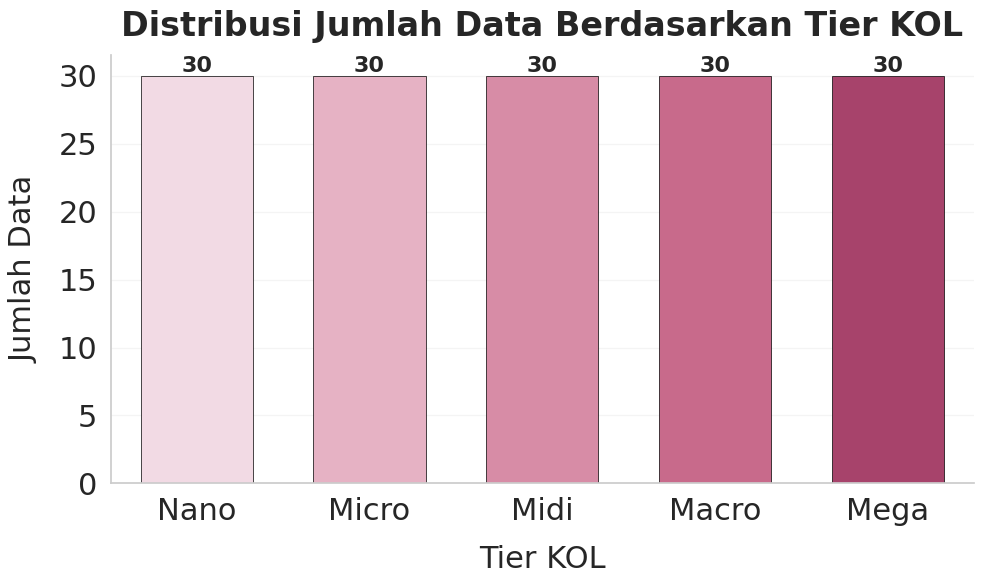

In [ ]:
plt.figure(figsize=(10,6))

pink_palette = ['#F6D6E3', '#EFA9C1', '#E47FA2', '#D85A86', '#B83268']

ax = sns.countplot(
    data=df_model,
    x='kol_tier',
    hue='kol_tier',
    palette=pink_palette,
    legend=False,
    edgecolor='black',
    linewidth=0.5
)

# kecilin lebar bar
for bar in ax.patches:
    current_width = bar.get_width()
    new_width = 0.65
    diff = current_width - new_width
    bar.set_width(new_width)
    bar.set_x(bar.get_x() + diff / 2)

# angka di atas bar
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=16,
        weight='bold'
    )

plt.title(
    'Distribusi Jumlah Data Berdasarkan Tier KOL',
    fontsize=24,
    weight='bold',
    pad=14
)

plt.xlabel(
    'Tier KOL',
    fontsize=22,
    labelpad=14
)

plt.ylabel(
    'Jumlah Data',
    fontsize=22,
    labelpad=14
)

plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.savefig(
    "distribusi_jumlah_data_tier_kol.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

##**Analisis Tahapan Awal**

### **Analisis Statistik Deskriptif**

In [ ]:
# Statistik deskriptif metrik engagement utama
engagement_cols = ["views", "likes", "comments", "shares"]

df_endorse[engagement_cols].describe()

,views,likes,comments,shares
count,1.500000e+02,1.500000e+02,150.00000,150.000000
mean,1.550917e+06,7.810143e+04,498.66000,1436.933333
std,3.837488e+06,2.642992e+05,1847.60762,5999.806605
min,2.300000e+02,4.000000e+00,0.00000,0.000000
25%,6.070500e+03,5.700000e+01,6.00000,6.000000
50%,5.930000e+04,1.314000e+03,25.50000,40.000000
75%,5.121750e+05,1.750000e+04,166.25000,269.250000
max,2.330000e+07,1.800000e+06,17700.00000,60800.000000


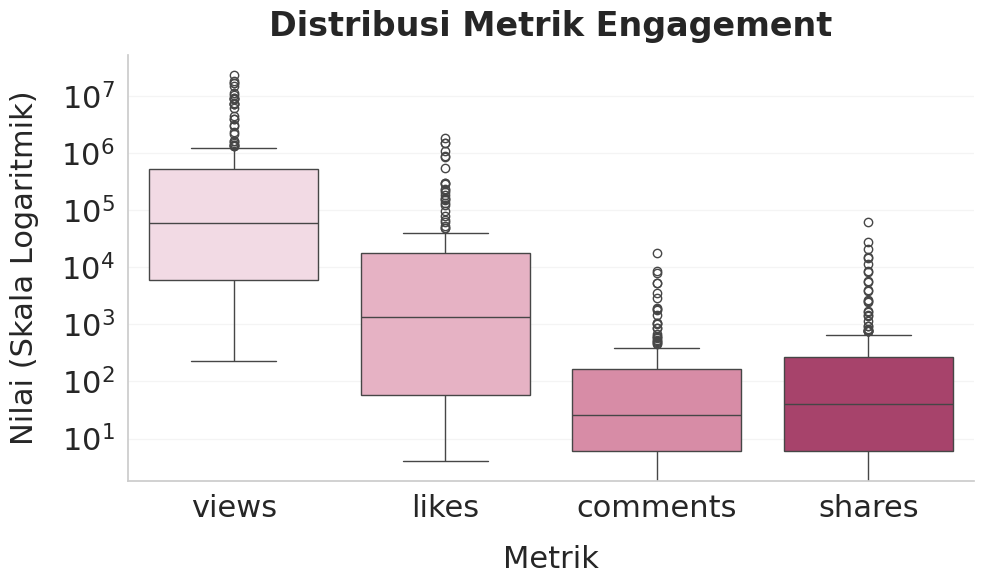

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_endorse[["views","likes","comments","shares"]],
    palette=["#F6D6E3", "#EFA9C1", "#E47FA2", "#B83268"],
    linewidth=1
)

plt.title(
    "Distribusi Metrik Engagement",
    fontsize=24,
    weight='bold',
    pad=14
)

plt.xlabel(
    "Metrik",
    fontsize=22,
    labelpad=16
)

plt.ylabel(
    "Nilai (Skala Logaritmik)",
    fontsize=22,
    labelpad=16
)

plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

plt.yscale("log")

plt.grid(
    axis='y',
    alpha=0.2
)

sns.despine()

plt.tight_layout()

plt.savefig(
    "boxplot_metrik_engagement.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
for col in engagement_cols:

    print(f"\n===== {col.upper()} =====")

    print("P90 :", df_endorse[col].quantile(0.90))
    print("P95 :", df_endorse[col].quantile(0.95))
    print("P99 :", df_endorse[col].quantile(0.99))
    print("Max :", df_endorse[col].max())


===== VIEWS =====
P90 : 6109999.9999999935
P95 : 9200000.0
P99 : 17358999.999999993
Max : 23300000

===== LIKES =====
P90 : 154449.99999999994
P95 : 294669.9999999999
P99 : 1500000.0
Max : 1800000

===== COMMENTS =====
P90 : 860.5999999999999
P95 : 1900.1999999999982
P99 : 8241.199999999993
Max : 17700

===== SHARES =====
P90 : 1779.0999999999958
P95 : 7180.899999999954
P99 : 23765.99999999994
Max : 60800


**Analisis**

---

Berdasarkan hasil statistik deskriptif, terlihat bahwa nilai minimum dan maksimum pada metrik views, likes, comments, dan shares memiliki rentang yang cukup jauh. Hal ini menunjukkan adanya perbedaan performa engagement antar postingan.

Selain itu, nilai mean yang lebih tinggi dibanding median menunjukkan bahwa distribusi data cenderung right-skewed, yaitu terdapat beberapa postingan dengan engagement sangat tinggi yang memengaruhi rata-rata data.

Nilai standar deviasi yang cukup besar juga menunjukkan bahwa persebaran data tidak homogen dan terdapat variasi engagement yang tinggi antar konten.

Berdasarkan kondisi tersebut, diperlukan analisis anomali untuk mengidentifikasi postingan dengan pola engagement yang berbeda dari mayoritas data.





### **Analisis Distribusi Engagement**

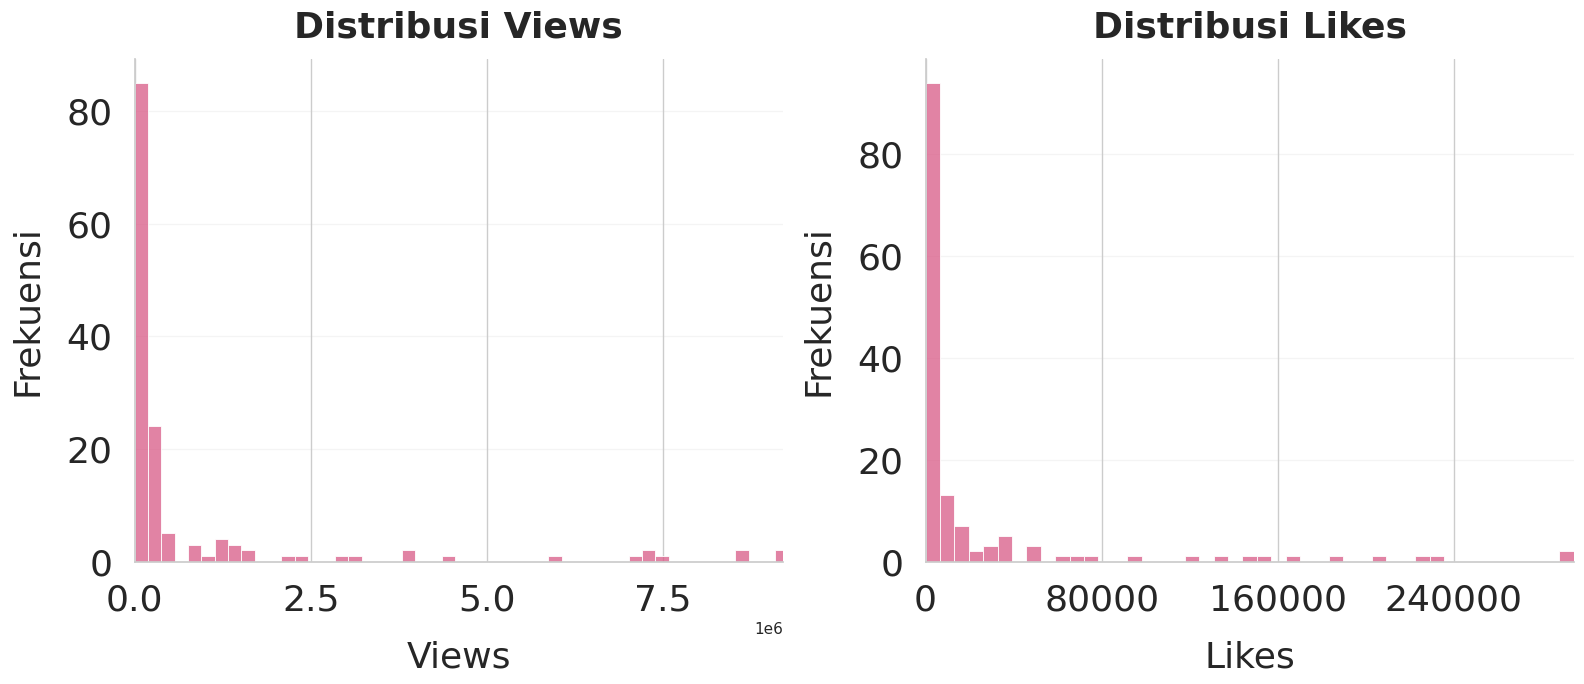

In [ ]:
from matplotlib.ticker import MaxNLocator

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cols = ['views', 'likes']

for i, col in enumerate(cols):

    upper_limit = df_endorse[col].quantile(0.95)

    sns.histplot(
        df_endorse[col],
        kde=False,
        ax=axes[i],
        color='#D85A86',
        edgecolor='white',
        linewidth=0.6
    )

    axes[i].set_xlim(0, upper_limit)

    axes[i].set_title(
        f'Distribusi {col.capitalize()}',
        fontsize=26,
        weight='bold',
        pad=16
    )

    axes[i].set_xlabel(
        col.capitalize(),
        fontsize=26,
        labelpad=16
    )

    axes[i].set_ylabel(
        'Frekuensi',
        fontsize=26,
        labelpad=16
    )

    axes[i].tick_params(
    axis='both',
    labelsize=26,
    pad=10
)

    axes[i].xaxis.set_major_locator(MaxNLocator(4))

    axes[i].grid(
        axis='y',
        alpha=0.2
    )

sns.despine()

plt.tight_layout()

plt.savefig(
    'distribusi_views_likes_p95.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

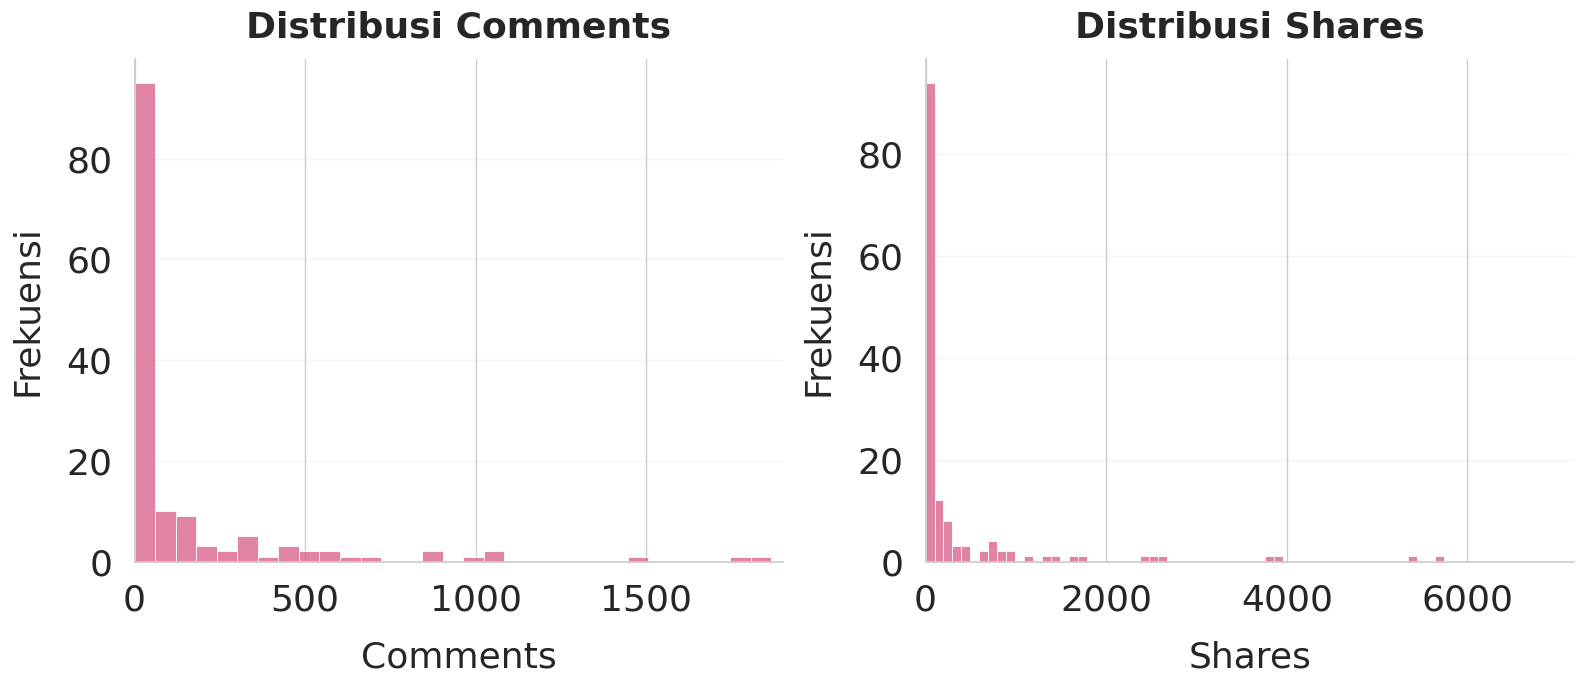

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cols = ['comments', 'shares']

for i, col in enumerate(cols):

    upper_limit = df_endorse[col].quantile(0.95)

    sns.histplot(
        df_endorse[col],
        kde=False,
        ax=axes[i],
        color='#D85A86',
        edgecolor='white',
        linewidth=0.6
    )

    axes[i].set_xlim(0, upper_limit)

    axes[i].set_title(
        f'Distribusi {col.capitalize()}',
        fontsize=26,
        weight='bold',
        pad=16
    )

    axes[i].set_xlabel(
        col.capitalize(),
        fontsize=26,
        labelpad=16
    )

    axes[i].set_ylabel(
        'Frekuensi',
        fontsize=26,
        labelpad=16
    )

    axes[i].tick_params(
        axis='both',
        labelsize=26,
        pad=10
    )

    axes[i].grid(
        axis='y',
        alpha=0.2
    )

sns.despine()

plt.tight_layout()

plt.savefig(
    'distribusi_comments_shares_p95.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### **Perhitungan Metrik Turunan (Rule-Based Metrics)**

In [ ]:
df_endorse["er"]  = (df_endorse["likes"] + df_endorse["comments"] + df_endorse["shares"]) / df_endorse["views"]
df_endorse["lvr"] = df_endorse["likes"] / df_endorse["views"]
df_endorse["cvr"] = df_endorse["comments"] / df_endorse["views"]
df_endorse["svr"] = df_endorse["shares"] / df_endorse["views"]
df_endorse

,post_code,post_url,post_date,username_kol,followers,kol_tier,is_endorse,likes,comments,shares,views,lvr,cvr,svr,er
0,post_1,https://www.tiktok.com/@mimaoo__/video/7553881...,2025-09-25,mimaoo__,1353,Nano,endorse,45,3,0,471,0.095541,0.006369,0.000000e+00,0.101911
1,post_2,https://www.tiktok.com/@mimaoo__/video/7552552...,2025-09-21,mimaoo__,1353,Nano,endorse,41,1,0,325,0.126154,0.003077,0.000000e+00,0.129231
2,post_3,https://www.tiktok.com/@mimaoo__/photo/7552384...,2025-09-21,mimaoo__,1353,Nano,endorse,28,2,0,854,0.032787,0.002342,0.000000e+00,0.035129
6,post_7,https://www.tiktok.com/@mamah_freddy/video/754...,2025-09-04,mamah_freddy,44300,Micro,endorse,47,4,1,2300000,0.000020,0.000002,4.347826e-07,0.000023
7,post_8,https://www.tiktok.com/@mamah_freddy/video/755...,2025-09-26,mamah_freddy,44300,Micro,endorse,47,4,1,12800,0.003672,0.000313,7.812500e-05,0.004063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290,post_291,https://vt.tiktok.com/ZSyYGTjKe/,2025-10-07,jolinnaaa,502100,Macro,endorse,1500000,3479,20400,17800000,0.084270,0.000195,1.146067e-03,0.085611
292,post_293,https://vt.tiktok.com/ZSyYGt3Lr/,2025-09-28,jolinnaaa,502100,Macro,endorse,227300,635,2455,3900000,0.058282,0.000163,6.294872e-04,0.059074
295,post_296,https://vt.tiktok.com/ZSyYtbchU/,2025-10-16,cataalcorse,1100000000,Mega,endorse,153300,358,767,1300000,0.117923,0.000275,5.900000e-04,0.118788
297,post_298,https://vt.tiktok.com/ZSyYttCW4/,2025-10-08,cataalcorse,1100000000,Mega,endorse,289800,445,2627,3900000,0.074308,0.000114,6.735897e-04,0.075095


In [ ]:
for col in ["er", "lvr", "cvr", "svr"]:
    df_model[col] = (
        df_model[col]
        .astype(str)
        .str.replace(",", ".")
        .astype(float)
    )

### **Statistik Deskriptif Metrik Turunan**

In [ ]:
rule_cols = ["er", "lvr", "cvr", "svr"]
df_endorse[rule_cols].describe()

,er,lvr,cvr,svr
count,150.000000,150.000000,150.000000,150.000000
mean,0.039800,0.036740,0.001452,0.001608
std,0.047234,0.045954,0.005356,0.002748
min,0.000023,0.000020,0.000000,0.000000
25%,0.013689,0.010762,0.000170,0.000322
50%,0.025840,0.023010,0.000322,0.000717
75%,0.045480,0.041147,0.000621,0.001536
max,0.314485,0.312907,0.059448,0.018809


In [ ]:
boxplot_df = df_model[['er','lvr','cvr','svr']].copy()

boxplot_df.columns = ['ER', 'LVR', 'CVR', 'SVR']

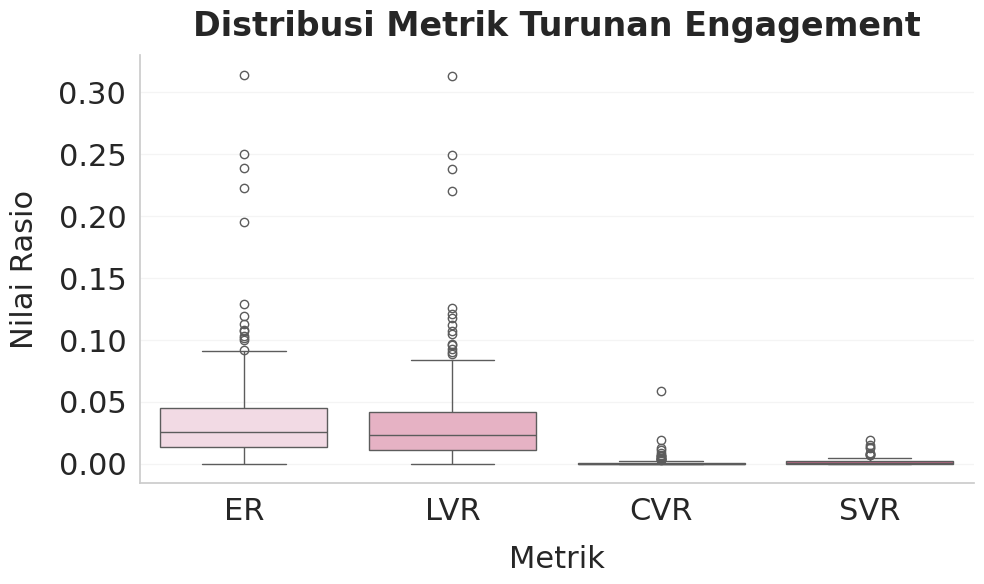

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=boxplot_df,
    palette=['#F6D6E3','#EFA9C1','#E47FA2','#D85A86']
)

plt.title(
    'Distribusi Metrik Turunan Engagement',
    fontsize=24,
    weight='bold',
    pad=14
)

plt.xlabel(
    'Metrik',
    fontsize=22,
    labelpad=14
)

plt.ylabel(
    'Nilai Rasio',
    fontsize=22,
    labelpad=14
)

plt.xticks(
    fontsize=22
)

plt.yticks(
    fontsize=22
)

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.savefig(
    "boxplot_metrik_turunan.png",
    dpi=400,
    bbox_inches='tight'
)

plt.show()

**Analisis**

---
Berdasarkan hasil statistik deskriptif fitur turunan, terlihat bahwa metrik ER, LVR, CVR, dan SVR memiliki distribusi yang cukup bervariasi antar postingan. Hal ini dapat dilihat dari perbedaan nilai minimum dan maksimum yang cukup jauh pada setiap metrik.

Nilai mean yang cenderung lebih tinggi dibanding median juga menunjukkan bahwa distribusi data bersifat right-skewed, di mana terdapat beberapa postingan dengan rasio engagement yang jauh lebih tinggi dibanding mayoritas data.

Selain itu, nilai standar deviasi yang relatif besar, terutama pada ER dan LVR, menunjukkan adanya variasi pola interaksi audiens antar konten. Kondisi ini mengindikasikan bahwa beberapa postingan memiliki karakteristik engagement yang berbeda dari mayoritas data, sehingga fitur turunan ini berpotensi digunakan dalam proses eksplorasi dan deteksi anomali.


### **Analisis Distribusi Metrik Turunan**

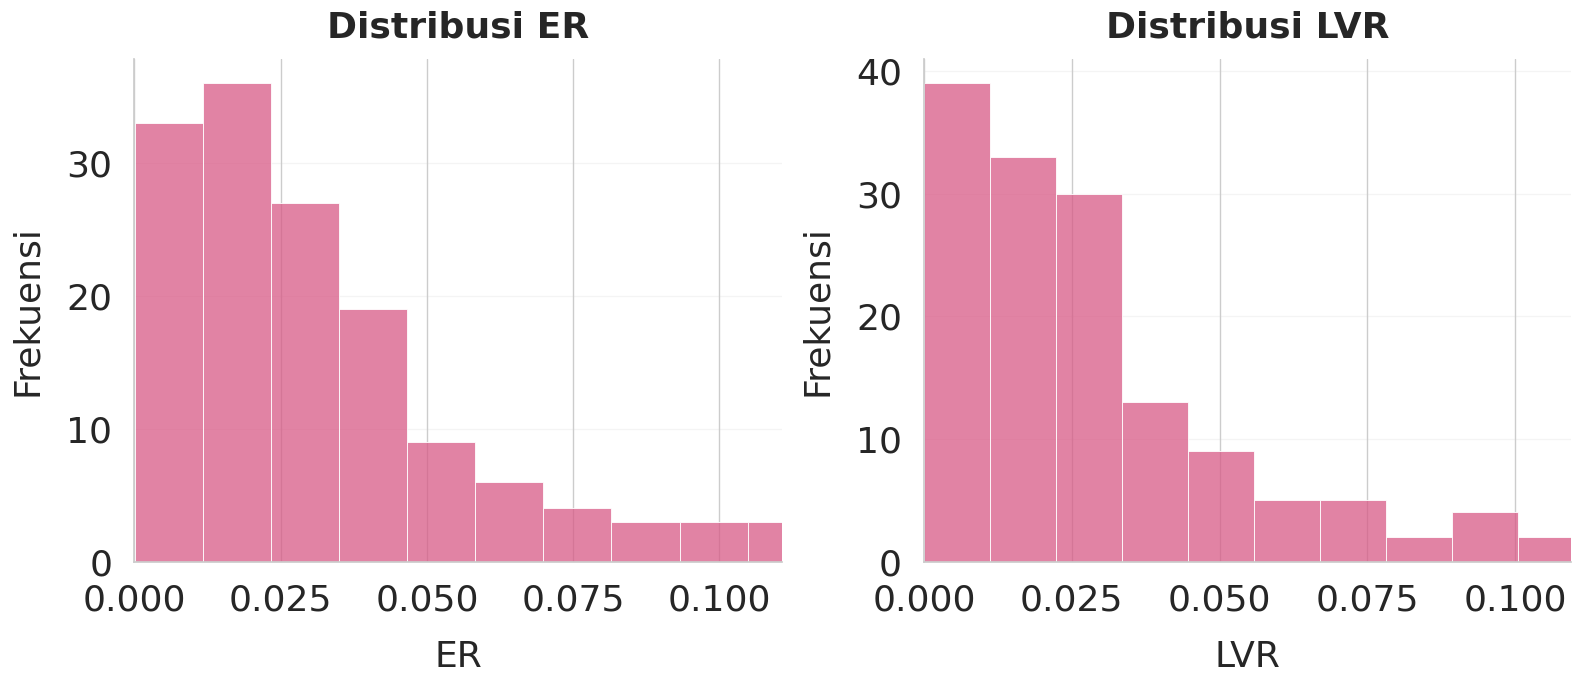

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cols = ['er', 'lvr']

for i, col in enumerate(cols):

    upper_limit = df_endorse[col].quantile(0.95)

    sns.histplot(
        df_endorse[col],
        kde=False,
        ax=axes[i],
        color='#D85A86',
        edgecolor='white',
        linewidth=0.6
    )

    axes[i].set_xlim(0, upper_limit)

    # ER LVR kapital
    label_name = col.upper()

    axes[i].set_title(
        f'Distribusi {label_name}',
        fontsize=26,
        weight='bold',
        pad=16
    )

    axes[i].set_xlabel(
        label_name,
        fontsize=26,
        labelpad=16
    )

    axes[i].set_ylabel(
        'Frekuensi',
        fontsize=26,
        labelpad=16
    )

    axes[i].tick_params(
        axis='both',
        labelsize=26,
        pad=10
    )

    axes[i].grid(
        axis='y',
        alpha=0.2
    )

sns.despine()

plt.tight_layout()

plt.savefig(
    'distribusi_er_lvr_p95.png',
    dpi=400,
    bbox_inches='tight'
)

plt.show()

In [ ]:
print(df_endorse['cvr'].describe())

print("\nP90 :", df_endorse['cvr'].quantile(0.90))
print("P95 :", df_endorse['cvr'].quantile(0.95))
print("P99 :", df_endorse['cvr'].quantile(0.99))
print("Max :", df_endorse['cvr'].max())

count    150.000000
mean       0.001452
std        0.005356
min        0.000000
25%        0.000170
50%        0.000322
75%        0.000621
max        0.059448
Name: cvr, dtype: float64

P90 : 0.0031198004449538167
P95 : 0.005926369772610397
P99 : 0.01592664704550594
Max : 0.059447983014861996


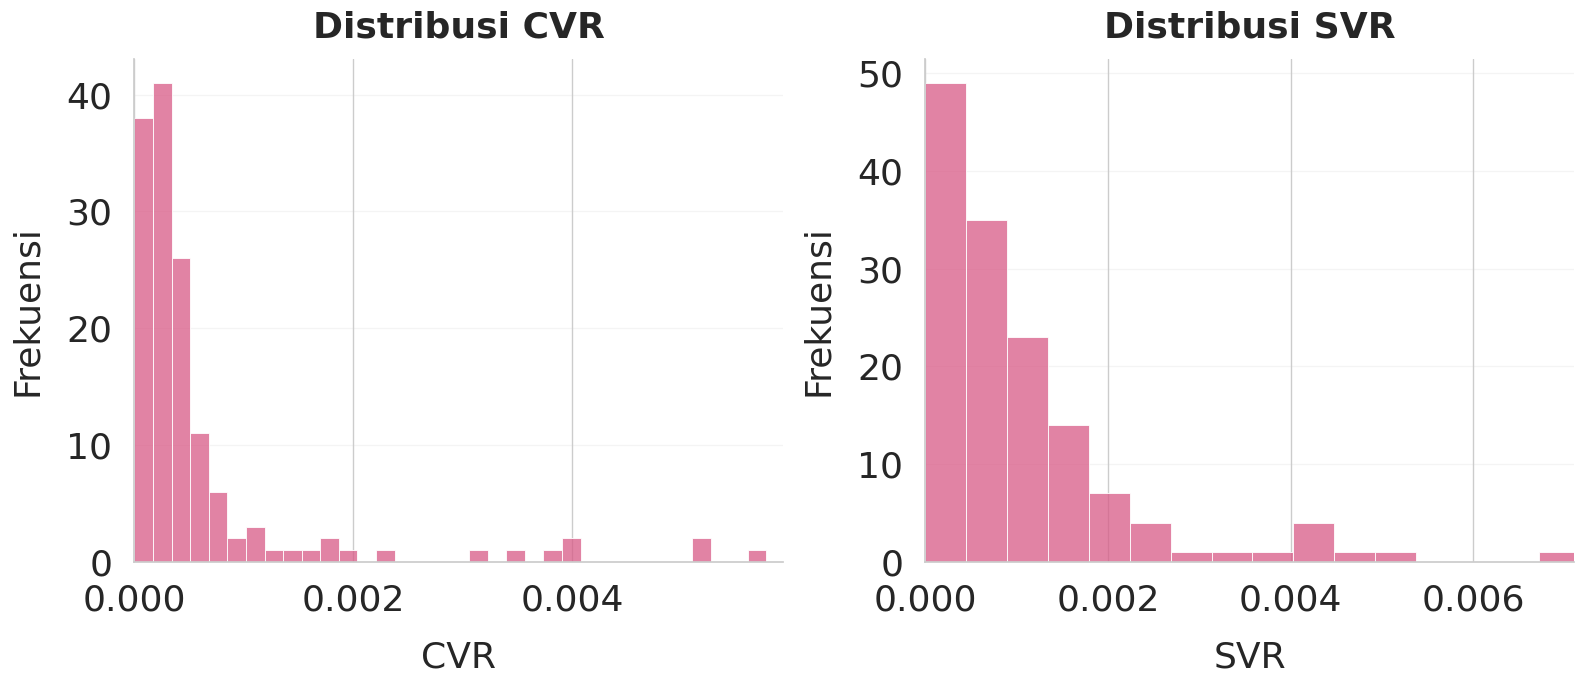

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cols = ['cvr', 'svr']

for i, col in enumerate(cols):

    upper_limit = df_endorse[col].quantile(0.95)

    sns.histplot(
        df_endorse[col],
        kde=False,
        ax=axes[i],
        color='#D85A86',
        edgecolor='white',
        linewidth=0.6
    )

    axes[i].set_xlim(0, upper_limit)

    label_name = col.upper()

    axes[i].set_title(
        f'Distribusi {label_name}',
        fontsize=26,
        weight='bold',
        pad=16
    )

    axes[i].set_xlabel(
        label_name,
        fontsize=26,
        labelpad=16
    )

    axes[i].set_ylabel(
        'Frekuensi',
        fontsize=26,
        labelpad=16
    )

    axes[i].tick_params(
        axis='both',
        labelsize=26,
        pad=10
    )

    axes[i].grid(
        axis='y',
        alpha=0.2
    )

sns.despine()

plt.tight_layout()

plt.savefig(
    'distribusi_cvr_svr_p95.png',
    dpi=400,
    bbox_inches='tight'
)

plt.show()

### **Uji Kewajaran Metrik Turunan dengan IQR**

**Hitung Q1 Q3 dan IQR**

In [ ]:
iqr_summary = {}

for col in rule_cols:
    Q1 = df_endorse[col].quantile(0.25)
    Q3 = df_endorse[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_bound = Q3 + 1.5 * IQR

    iqr_summary[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Upper_Bound": upper_bound
    }

iqr_df = pd.DataFrame(iqr_summary).T
iqr_df

,Q1,Q3,IQR,Upper_Bound
er,0.013689,0.045480,0.031792,0.093167
lvr,0.010762,0.041147,0.030385,0.086723
cvr,0.000170,0.000621,0.000451,0.001298
svr,0.000322,0.001536,0.001214,0.003356


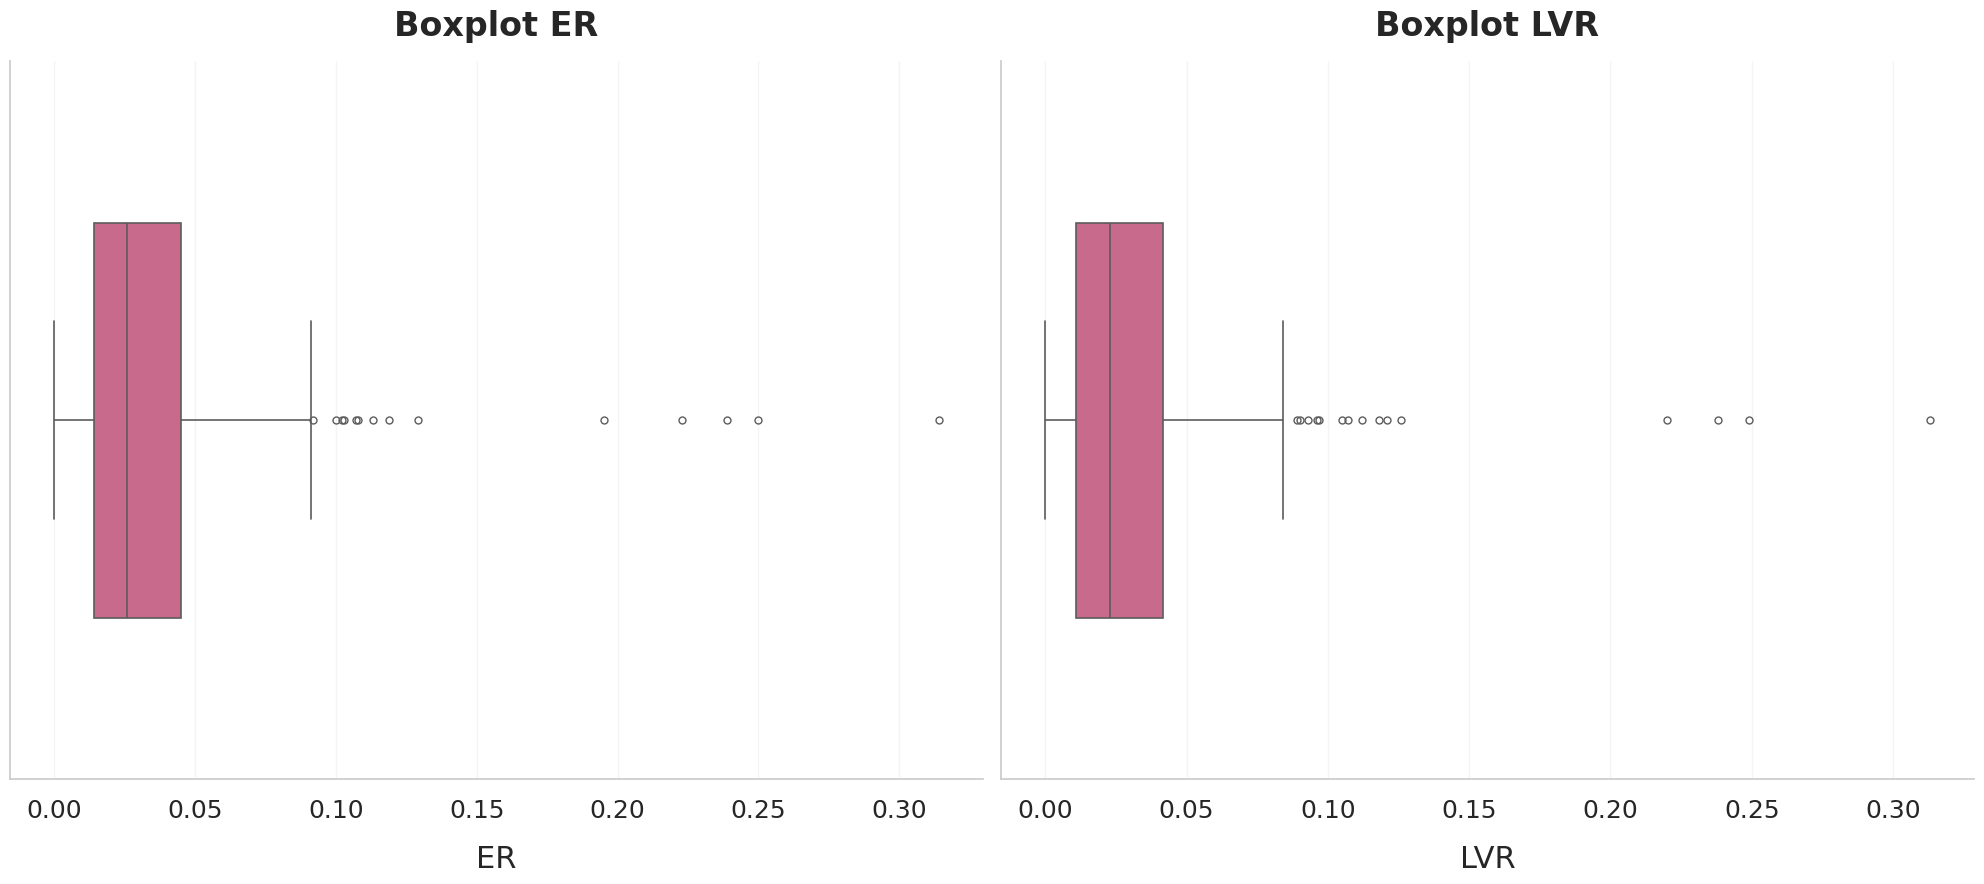

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

cols = ['er', 'lvr']

for i, col in enumerate(cols):

    sns.boxplot(
        x=df_model[col],
        ax=axes[i],
        color='#D85A86',
        width=0.55,
        linewidth=1.2,
        fliersize=5
    )

    axes[i].set_title(
        f'Boxplot {col.upper()}',
        fontsize=24,
        weight='bold',
        pad=18
    )

    axes[i].set_xlabel(
        col.upper(),
        fontsize=22,
        labelpad=16
    )

    axes[i].tick_params(
        axis='both',
        labelsize=18,
        pad=8
    )

    axes[i].grid(
        axis='x',
        alpha=0.2
    )

sns.despine()
plt.tight_layout()

plt.savefig(
    'boxplot_er_lvr.png',
    dpi=400,
    bbox_inches='tight'
)

plt.show()

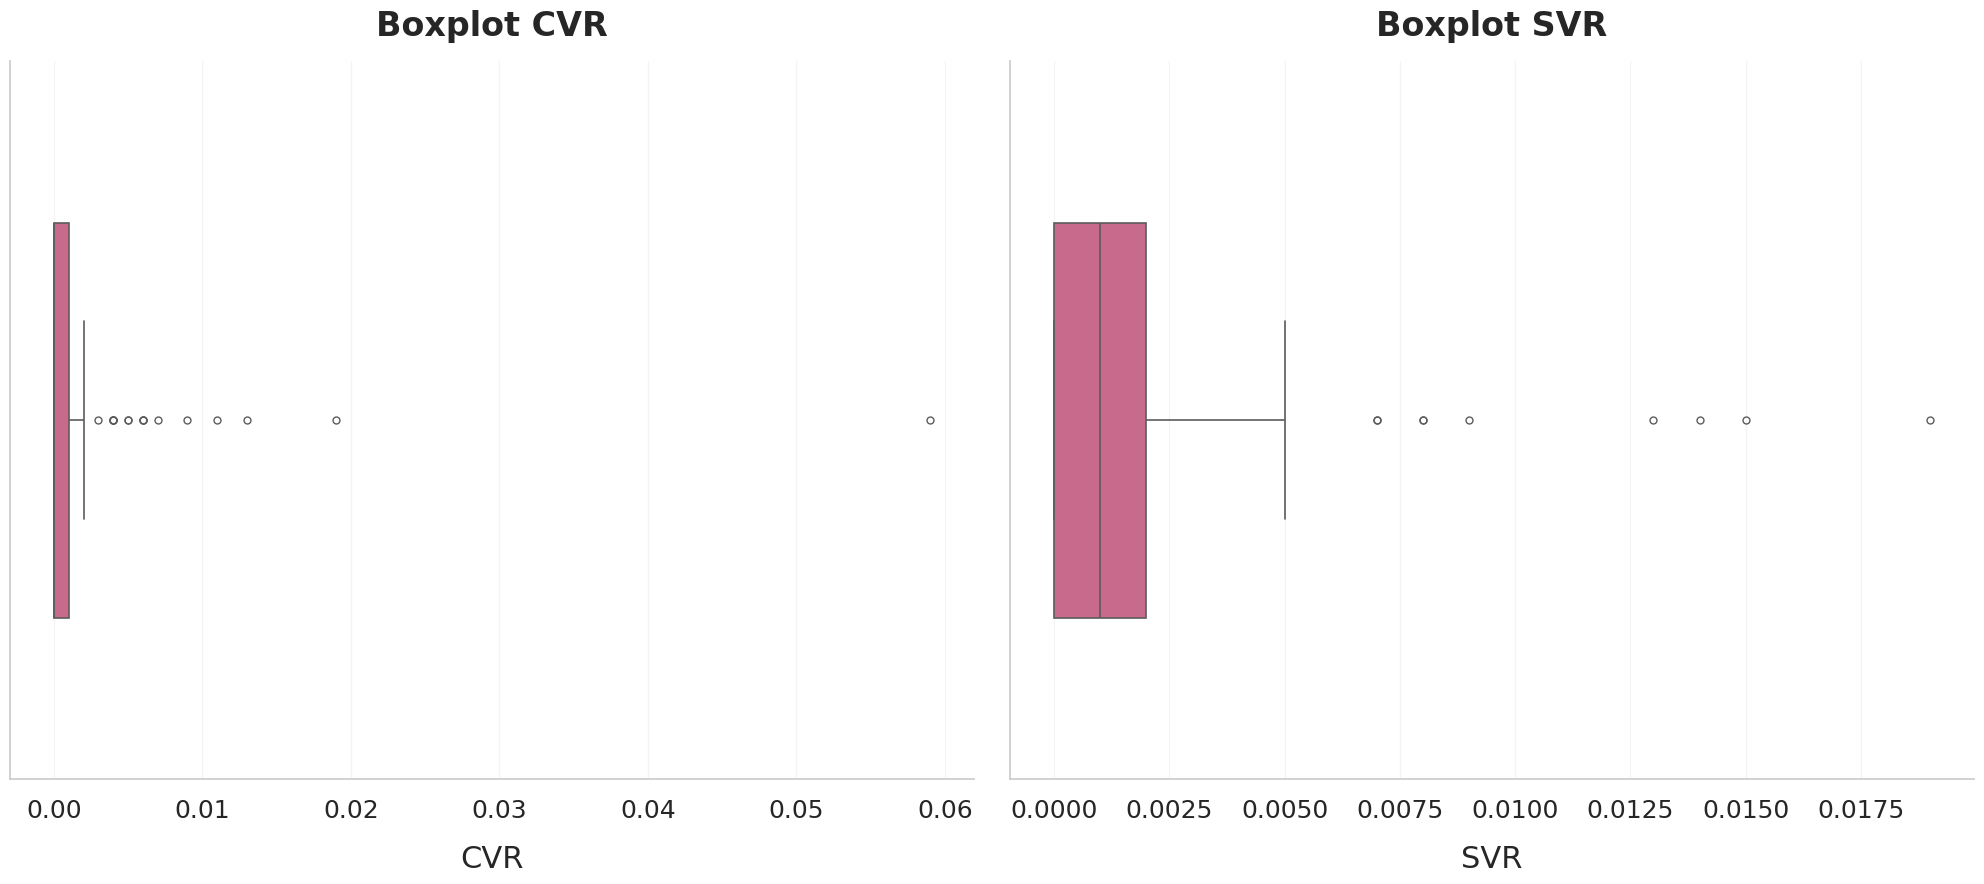

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

cols = ['cvr', 'svr']

for i, col in enumerate(cols):

    sns.boxplot(
        x=df_model[col],
        ax=axes[i],
        color='#D85A86',
        width=0.55,
        linewidth=1.2,
        fliersize=5
    )

    axes[i].set_title(
        f'Boxplot {col.upper()}',
        fontsize=24,
        weight='bold',
        pad=18
    )

    axes[i].set_xlabel(
        col.upper(),
        fontsize=22,
        labelpad=16
    )

    axes[i].tick_params(
        axis='both',
        labelsize=18,
        pad=8
    )

    axes[i].grid(
        axis='x',
        alpha=0.2
    )

sns.despine()
plt.tight_layout()

plt.savefig(
    'boxplot_cvr_svr.png',
    dpi=400,
    bbox_inches='tight'
)

plt.show()

### **Identifikasi Indikasi Awal Kejanggalan (Outlier Awal)**

In [ ]:
for col in rule_cols:
    upper = iqr_df.loc[col, "Upper_Bound"]
    df_endorse[f"{col}_iqr_flag"] = (df_endorse[col] > upper).astype(int)

In [ ]:
df_endorse[[f"{col}_iqr_flag" for col in rule_cols]].sum()

,0
er_iqr_flag,13
lvr_iqr_flag,15
cvr_iqr_flag,23
svr_iqr_flag,16


## **Feature Exploration**



**All Features**

In [ ]:
features = ["er", "lvr", "cvr", "svr", "views", "likes", "comments", "shares"]

In [ ]:
feature_pairs = list(combinations(features, 2))
print("Jumlah kombinasi:", len(feature_pairs))
feature_pairs

Jumlah kombinasi: 28


[('er', 'lvr'),
 ('er', 'cvr'),
 ('er', 'svr'),
 ('er', 'views'),
 ('er', 'likes'),
 ('er', 'comments'),
 ('er', 'shares'),
 ('lvr', 'cvr'),
 ('lvr', 'svr'),
 ('lvr', 'views'),
 ('lvr', 'likes'),
 ('lvr', 'comments'),
 ('lvr', 'shares'),
 ('cvr', 'svr'),
 ('cvr', 'views'),
 ('cvr', 'likes'),
 ('cvr', 'comments'),
 ('cvr', 'shares'),
 ('svr', 'views'),
 ('svr', 'likes'),
 ('svr', 'comments'),
 ('svr', 'shares'),
 ('views', 'likes'),
 ('views', 'comments'),
 ('views', 'shares'),
 ('likes', 'comments'),
 ('likes', 'shares'),
 ('comments', 'shares')]

In [ ]:
def plot_basic(df, feature_x, feature_y):
    plt.figure(figsize=(6,5))
    sns.scatterplot(data=df, x=feature_x, y=feature_y, color="blue")
    plt.title(f"{feature_x} vs {feature_y}")
    plt.show()

In [ ]:
results = []

for pair in feature_pairs:
    X = df_model[list(pair)]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    iso = IsolationForest(contamination=0.05, random_state=42)
    preds = iso.fit_predict(X_scaled)

    df_model["anomaly_flag"] = preds
    outliers = df_model[df_model["anomaly_flag"] == -1]

    results.append({
        "feature_1": pair[0],
        "feature_2": pair[1],
        "n_outliers": len(outliers),
        "outlier_post": outliers["post_code"].tolist()
    })

In [ ]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="n_outliers", ascending=False)

,feature_1,feature_2,n_outliers,outlier_post
0,er,lvr,8,"[post_2, post_7, post_62, post_171, post_173, ..."
1,er,cvr,8,"[post_2, post_62, post_93, post_100, post_171,..."
2,er,svr,8,"[post_2, post_34, post_35, post_62, post_171, ..."
3,er,views,8,"[post_79, post_81, post_104, post_173, post_23..."
4,er,likes,8,"[post_57, post_79, post_81, post_173, post_236..."
5,er,comments,8,"[post_49, post_81, post_171, post_173, post_17..."
6,er,shares,8,"[post_49, post_79, post_171, post_173, post_23..."
7,lvr,cvr,8,"[post_2, post_62, post_93, post_100, post_171,..."
8,lvr,svr,8,"[post_34, post_35, post_62, post_171, post_173..."
9,lvr,views,8,"[post_79, post_81, post_104, post_171, post_17..."


### **Analisis Scatterplot derived feature**

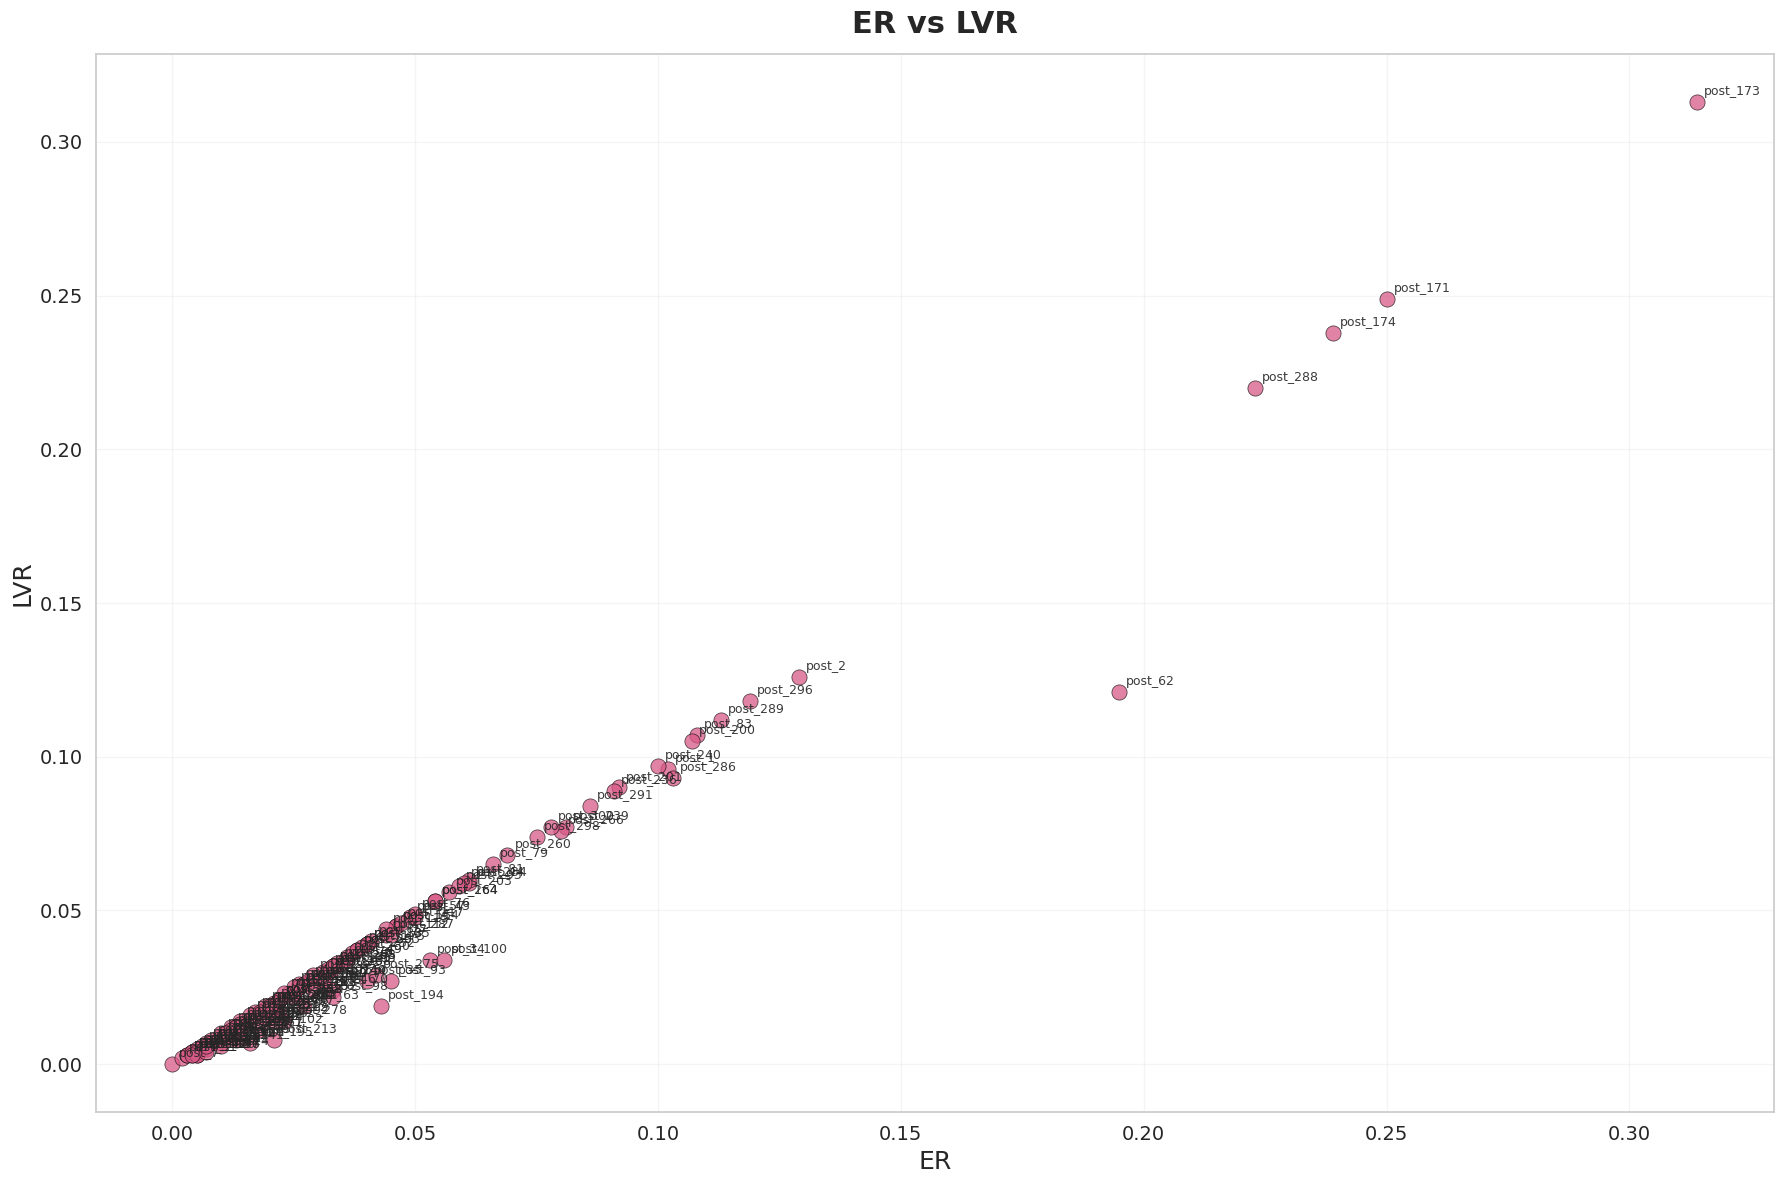

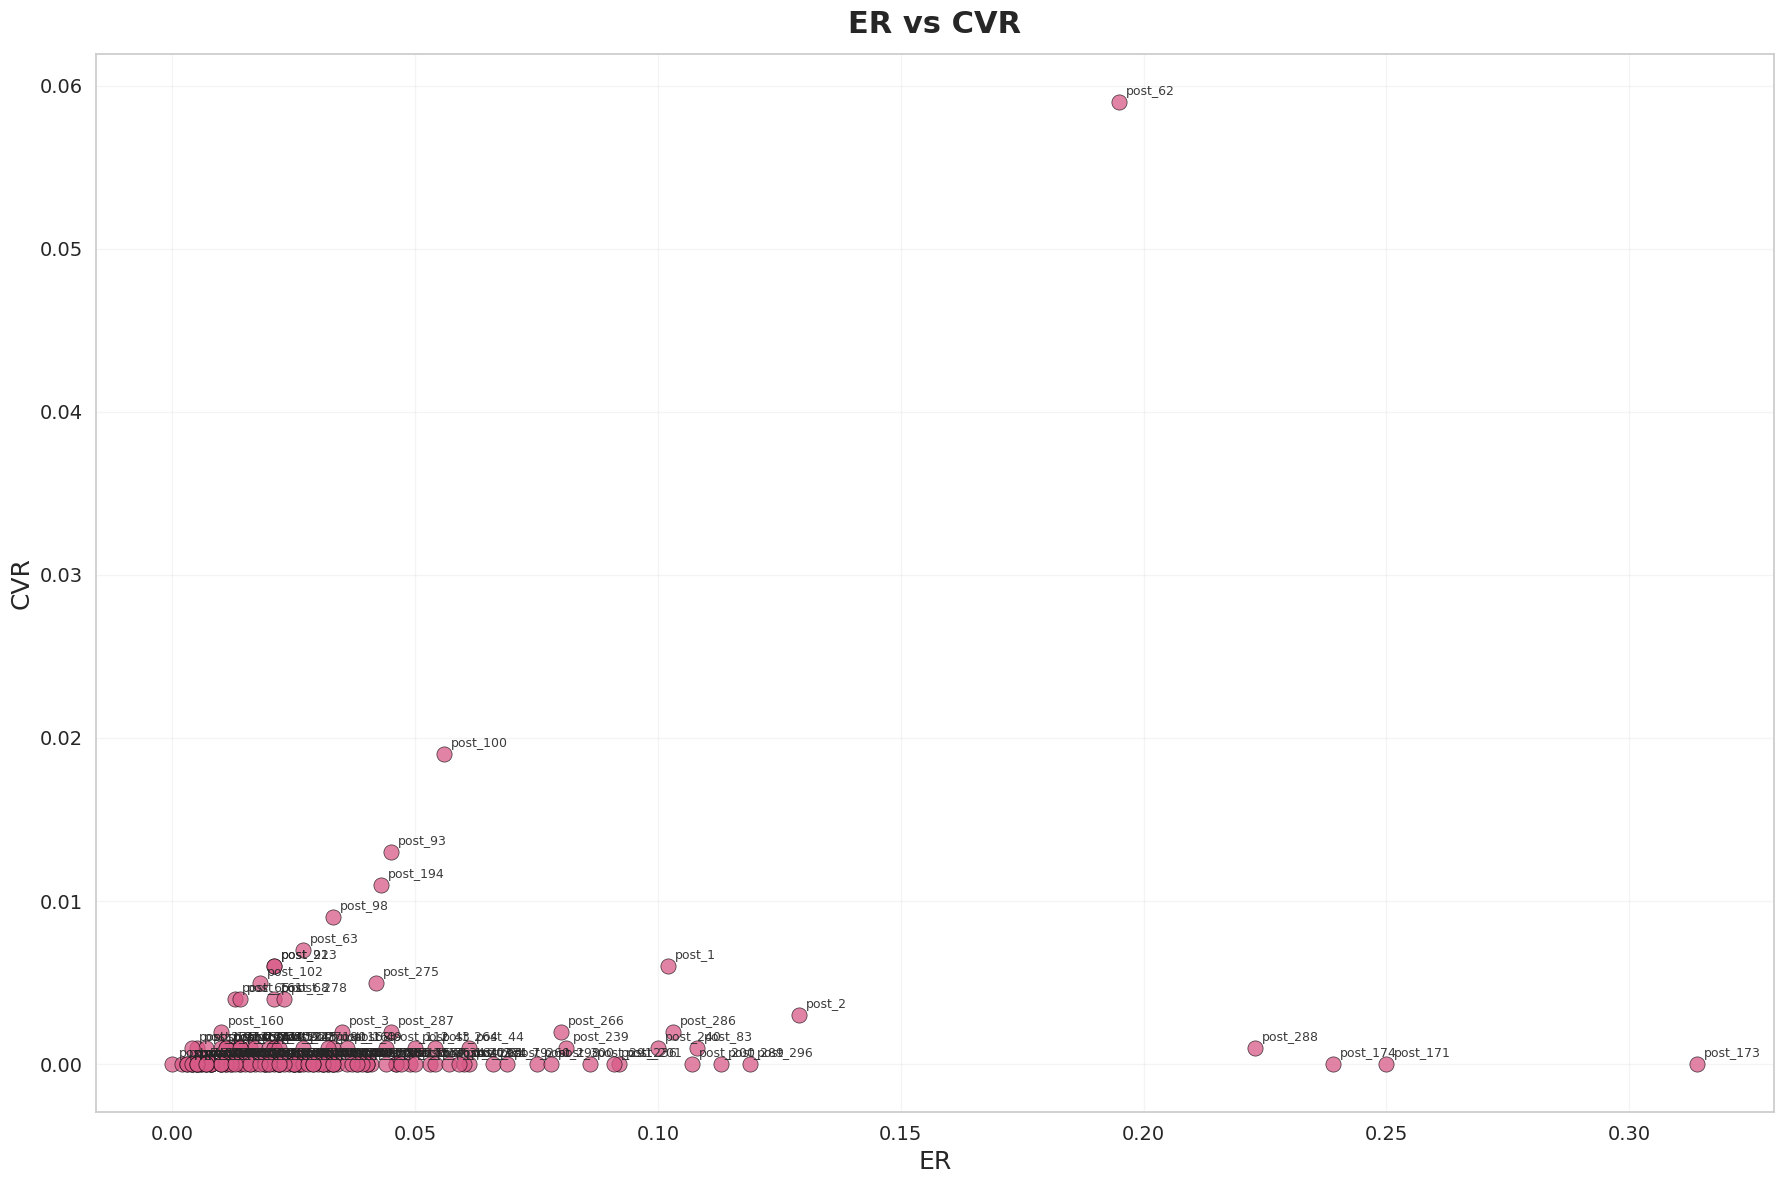

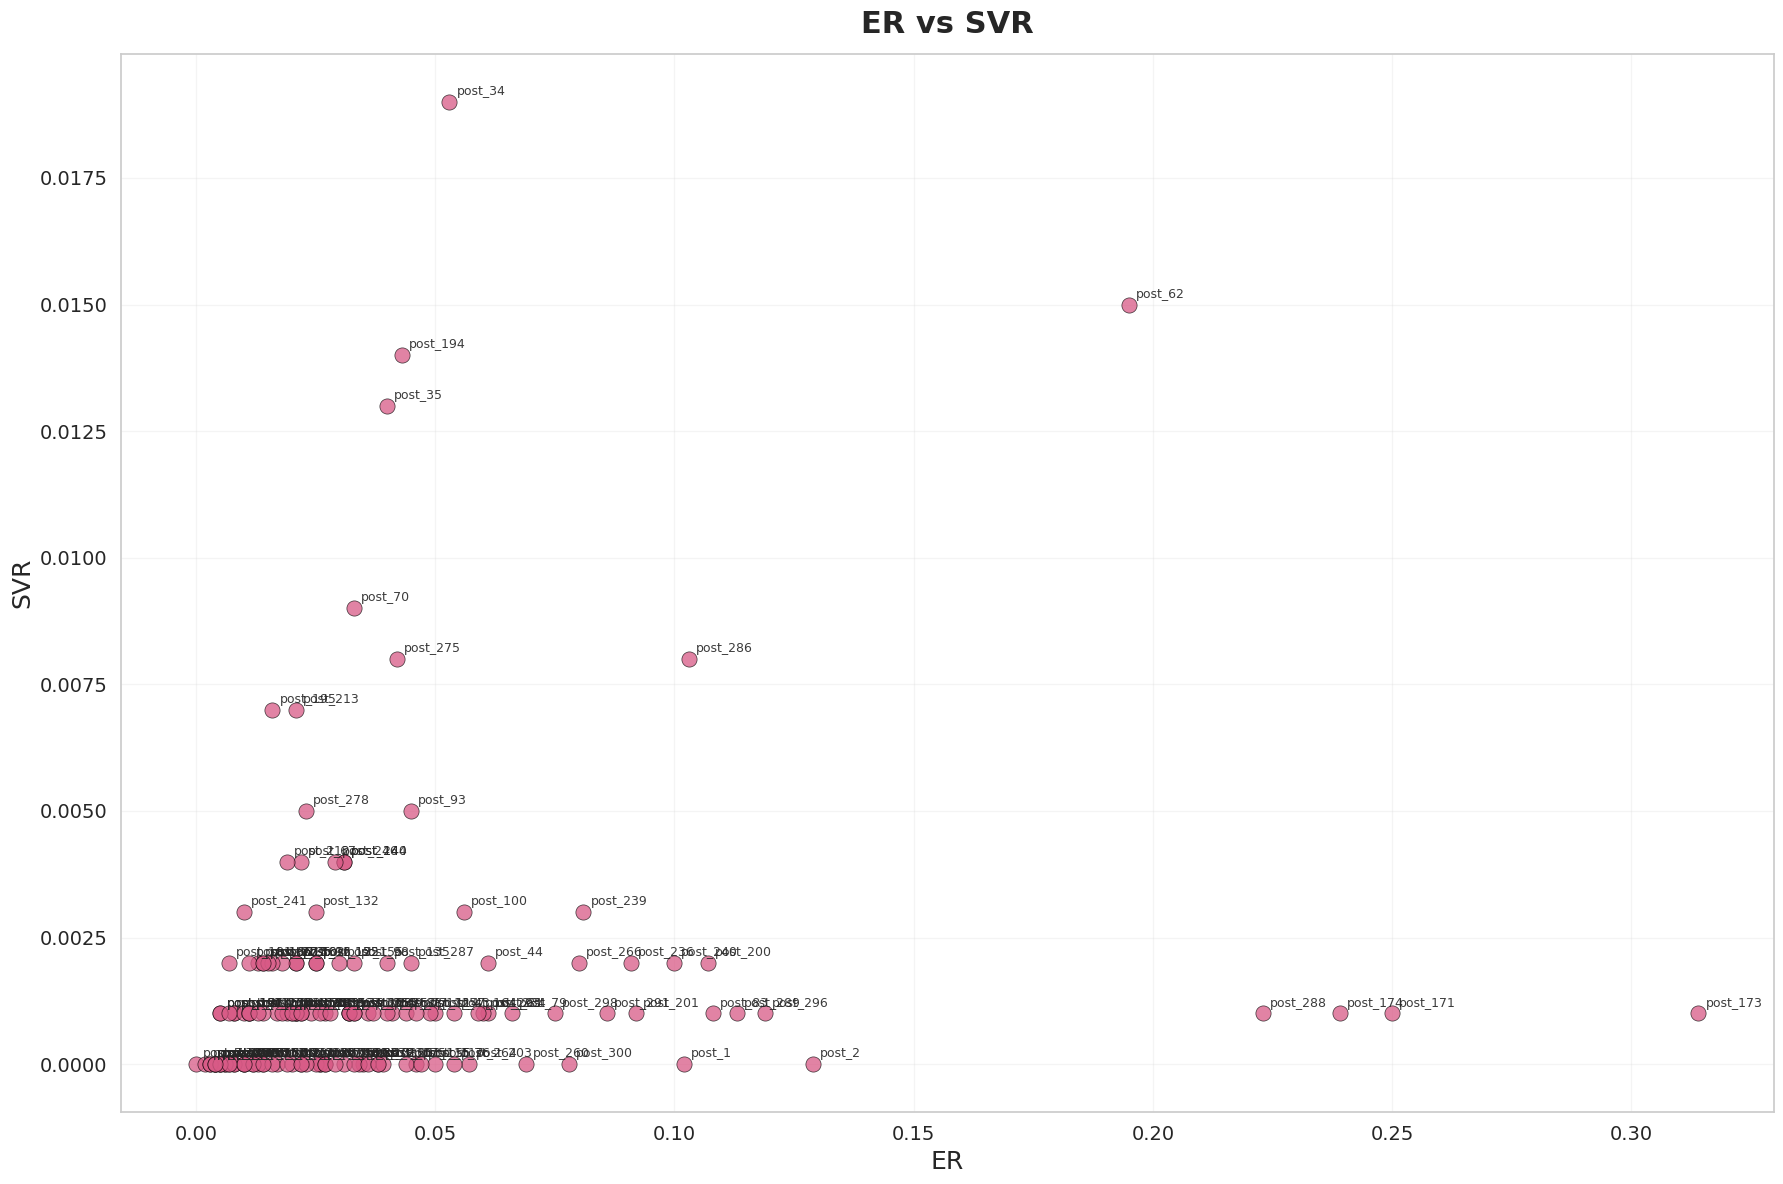

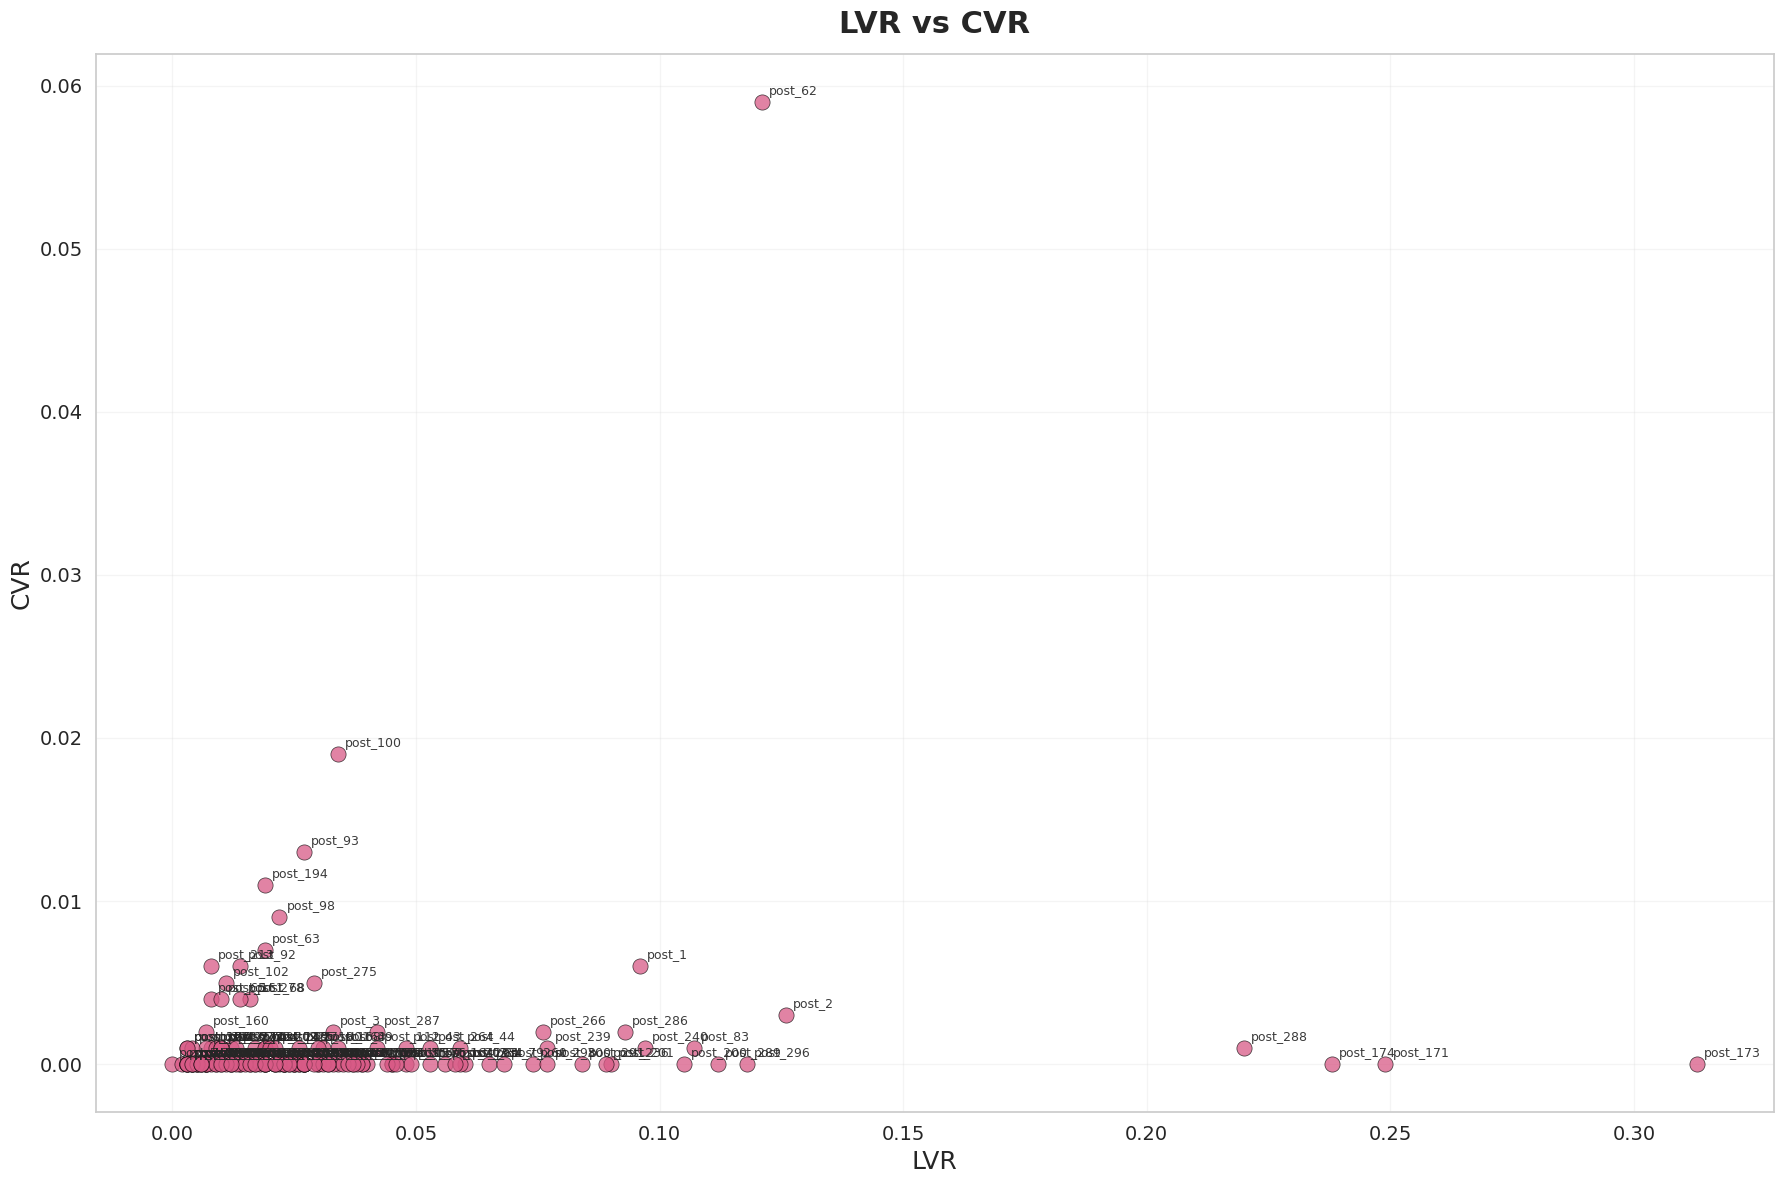

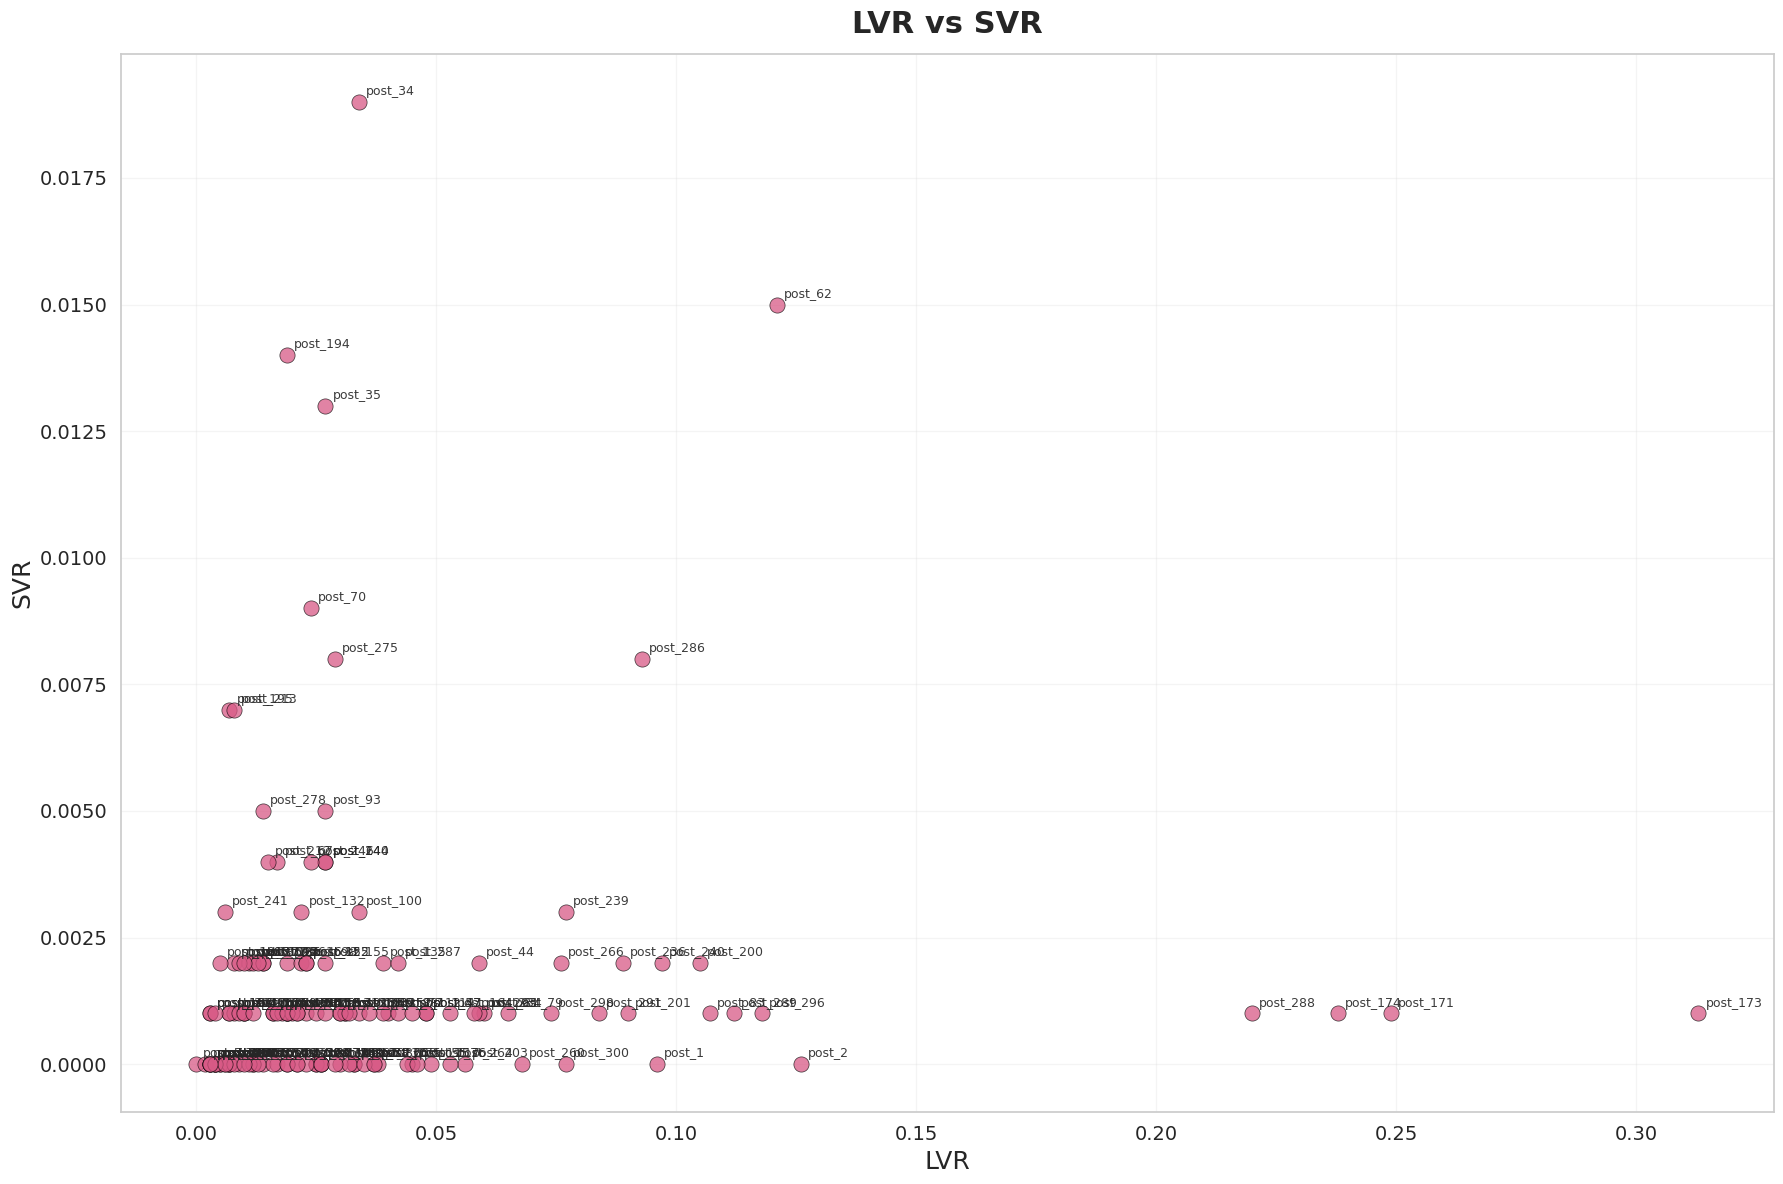

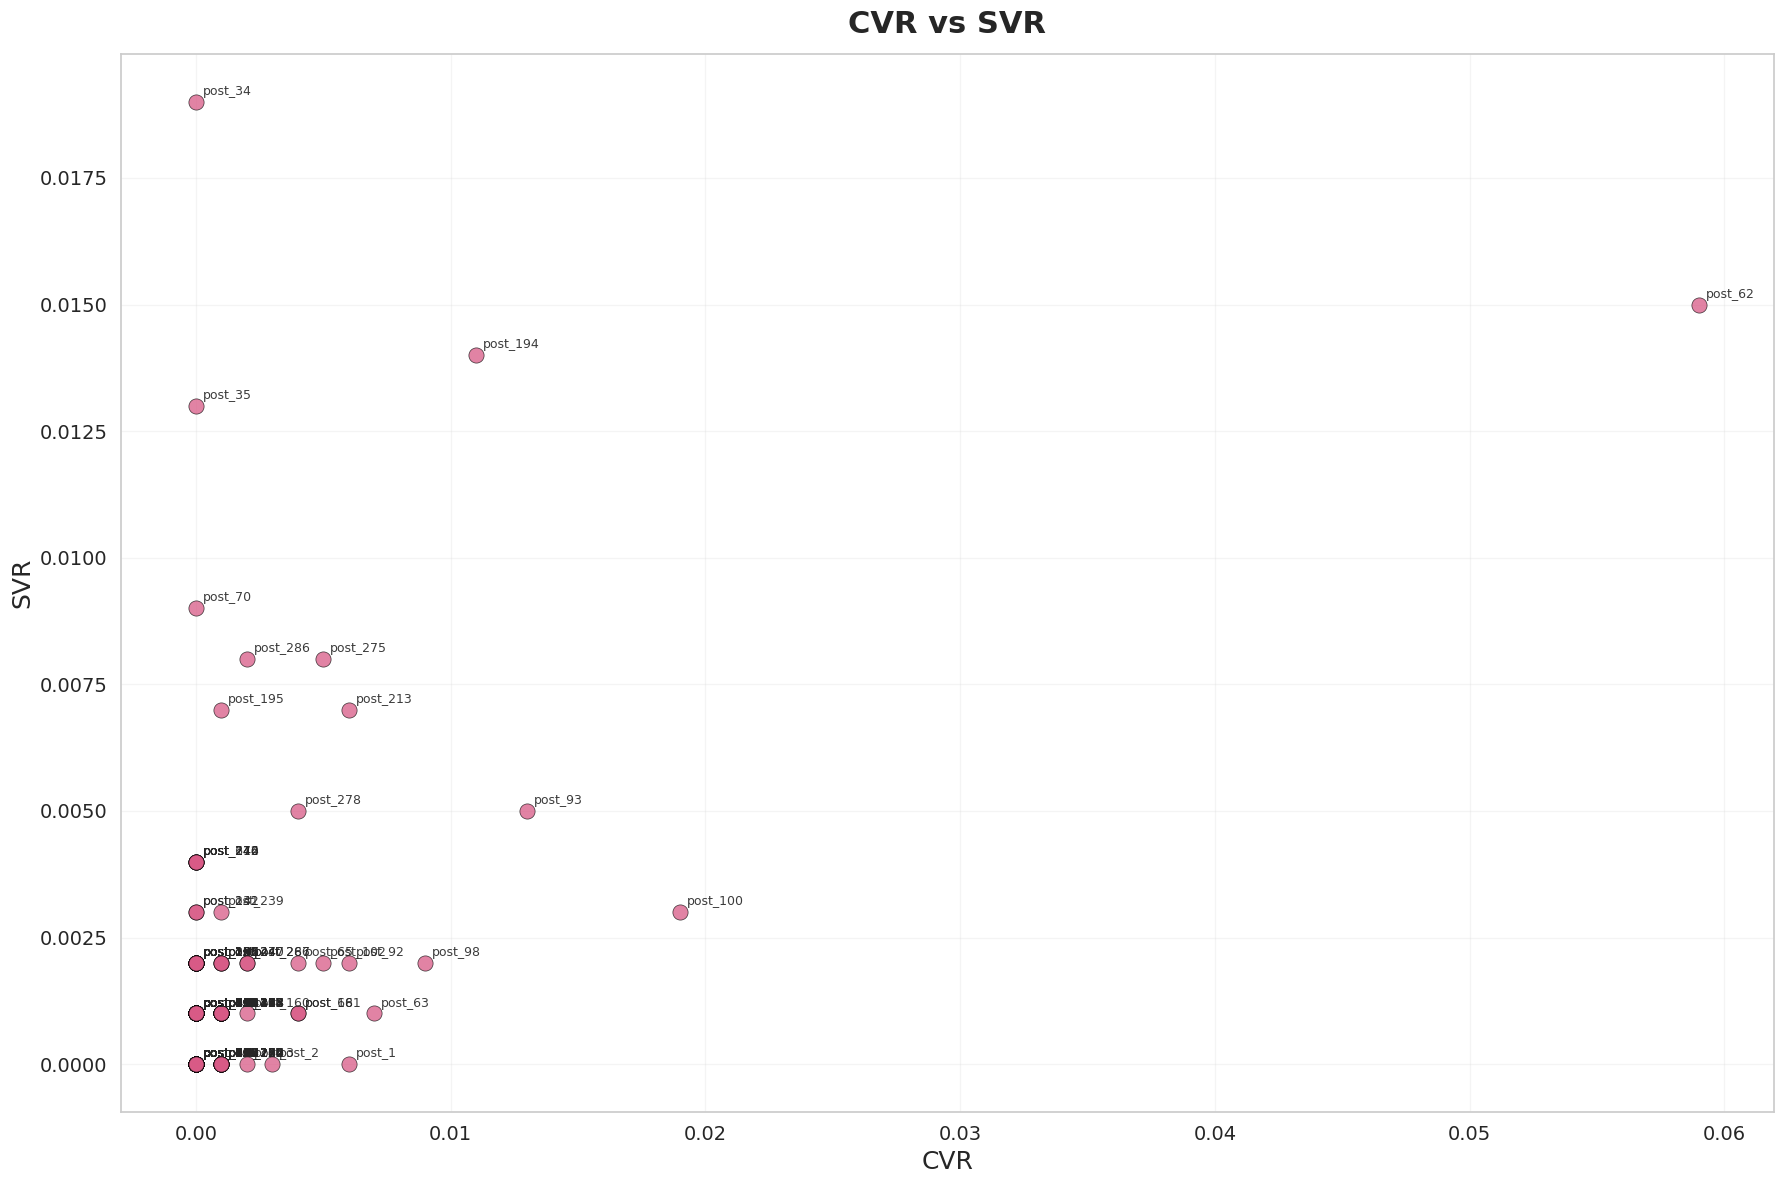

In [ ]:
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns

features = ["er", "lvr", "cvr", "svr"]
feature_pairs = list(combinations(features, 2))

for x_feat, y_feat in feature_pairs:

    fig, ax = plt.subplots(figsize=(18, 12))

    sns.scatterplot(
        data=df_model,
        x=x_feat,
        y=y_feat,
        color="#D85A86",
        s=120,
        alpha=0.75,
        edgecolor="black",
        linewidth=0.5,
        ax=ax
    )

    for _, row in df_model.iterrows():
        ax.annotate(
            row["post_code"],   # ganti jadi "post_code" kalau nama kolommu lowercase
            (row[x_feat], row[y_feat]),
            fontsize=9,
            alpha=0.9,
            xytext=(5, 5),
            textcoords="offset points"
        )

    ax.set_title(
        f"{x_feat.upper()} vs {y_feat.upper()}",
        fontsize=22,
        weight="bold",
        pad=15
    )

    ax.set_xlabel(x_feat.upper(), fontsize=18)
    ax.set_ylabel(y_feat.upper(), fontsize=18)
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(alpha=0.2)

    plt.tight_layout()

    filename = f"scatter_{x_feat}_{y_feat}_postcode.png"
    plt.savefig(filename, dpi=400, bbox_inches="tight")
    plt.show()

**Derived Features**

In [ ]:
feature_2 = ["er", "lvr", "cvr", "svr"]

In [ ]:
feature_pairs2 = list(combinations(feature_2, 2))
print("Jumlah kombinasi:", len(feature_pairs2))
feature_pairs2

Jumlah kombinasi: 6


[('er', 'lvr'),
 ('er', 'cvr'),
 ('er', 'svr'),
 ('lvr', 'cvr'),
 ('lvr', 'svr'),
 ('cvr', 'svr')]

In [ ]:
import math

def plot_all_derived(df, feature_pairs):

    total_plots = len(feature_pairs)

    # jumlah kolom subplot
    cols = 2
    rows = math.ceil(total_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))

    # biar gampang indexing
    axes = axes.flatten()

    # palette warna ungu/pink aesthetic
    colors = ['#c084fc', '#e879f9', '#a78bfa', '#f472b6', '#8b5cf6']

    for i, pair in enumerate(feature_pairs):

        feature_x = pair[0]
        feature_y = pair[1]

        sns.scatterplot(
            data=df,
            x=feature_x,
            y=feature_y,
            ax=axes[i],
            color=colors[i % len(colors)],
            s=60,          # ukuran titik
            alpha=0.7,     # transparansi
            edgecolor='black',
            linewidth=0.4
        )

        axes[i].set_title(
            f"{feature_x} vs {feature_y}",
            fontsize=11,
            weight='bold'
        )

        axes[i].grid(alpha=0.2)

    # hapus subplot kosong kalau jumlah plot ganjil
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

    # save otomatis
    plt.savefig(
        "scatterplot_derived_metrics.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

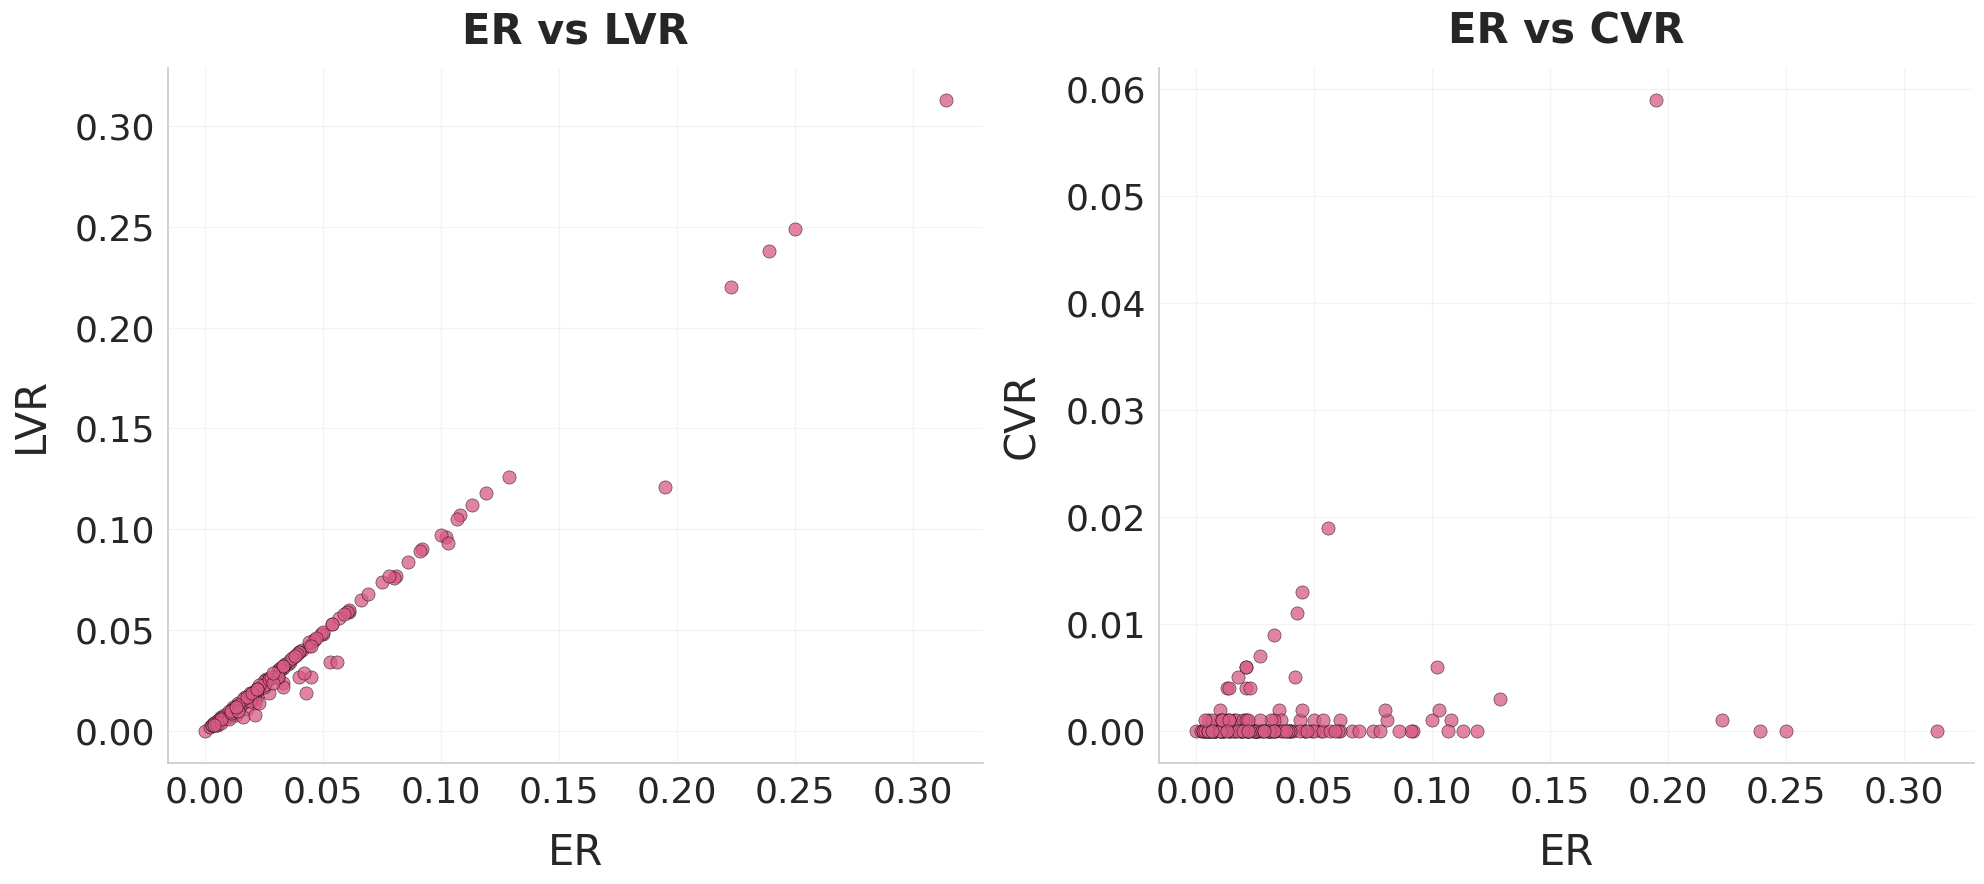

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

pairs = [('er', 'lvr'),
         ('er', 'cvr')]

for ax, pair in zip(axes, pairs):

    sns.scatterplot(
        data=df_model,
        x=pair[0],
        y=pair[1],
        color='#D85A86',
        s=90,
        alpha=0.75,
        edgecolor='black',
        linewidth=0.4,
        ax=ax
    )

    ax.set_title(
        f'{pair[0].upper()} vs {pair[1].upper()}',
        fontsize=30,
        weight='bold',
        pad=18
    )

    ax.set_xlabel(pair[0].upper(), fontsize=30, labelpad=16)
    ax.set_ylabel(pair[1].upper(), fontsize=30, labelpad=16)

    ax.tick_params(axis='both', labelsize=26)

    ax.grid(alpha=0.2)

sns.despine()
plt.tight_layout()

plt.savefig(
    'scatter_er_lvr_er_cvr.png',
    dpi=400,
    bbox_inches='tight'
)

plt.show()

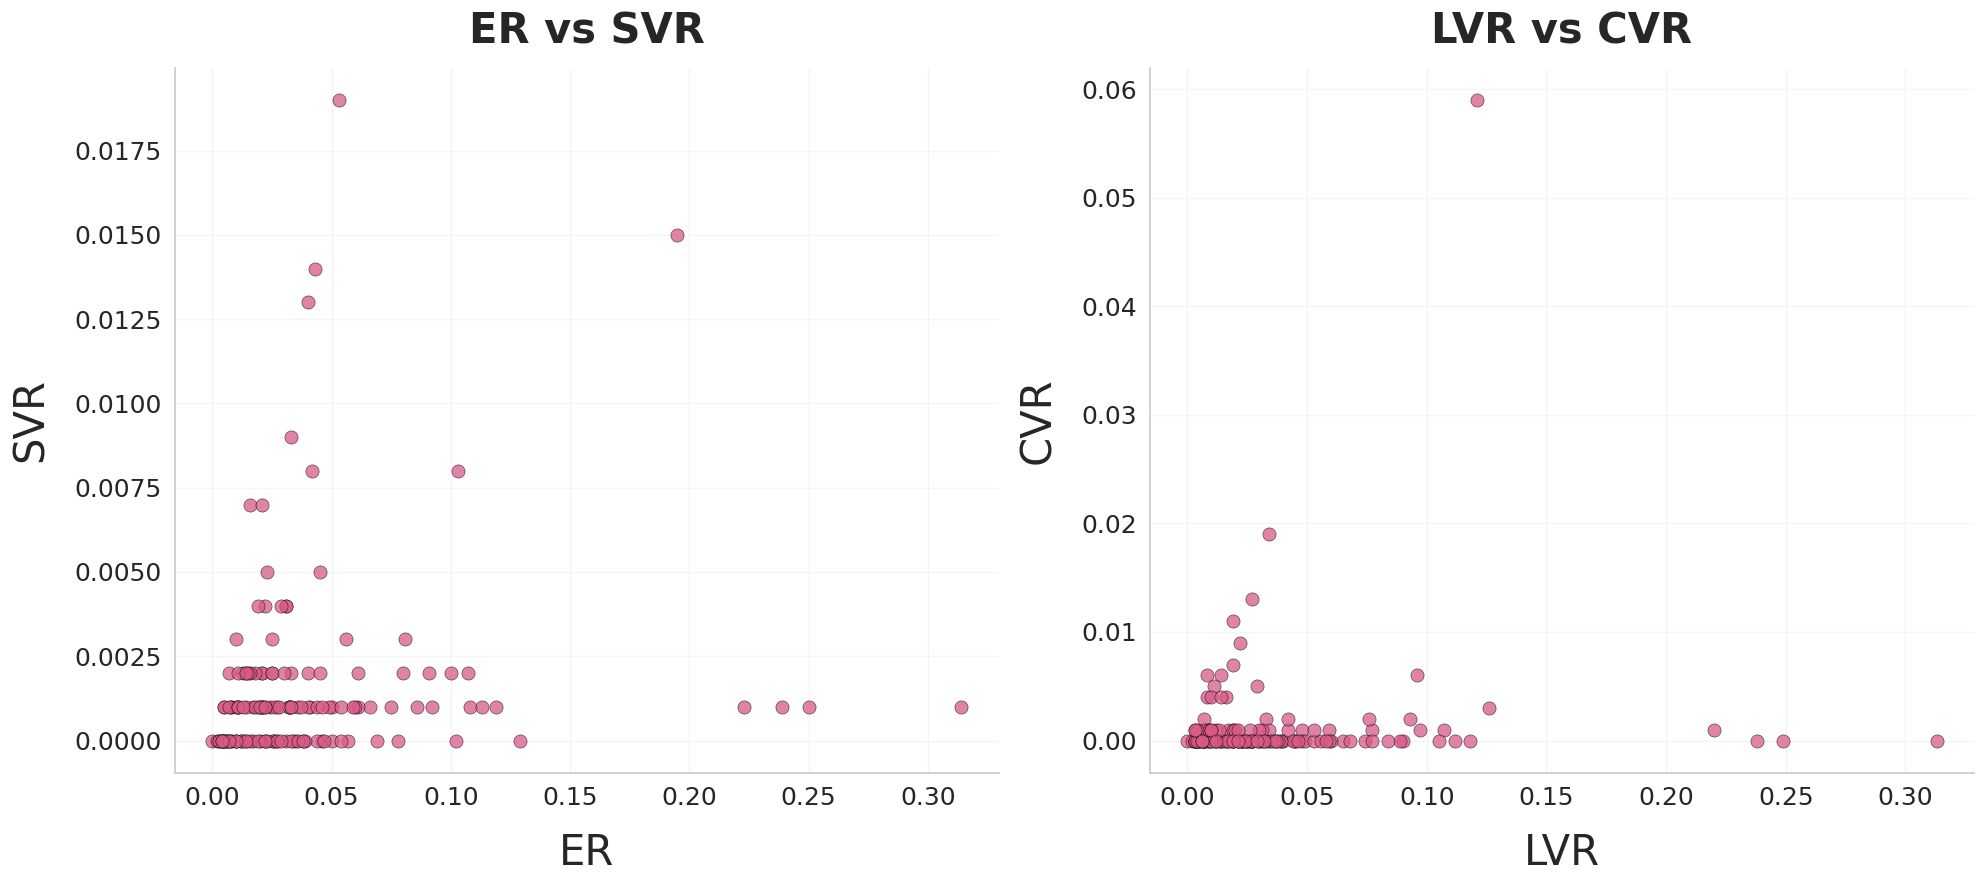

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

pairs = [('er', 'svr'),
         ('lvr', 'cvr')]

for ax, pair in zip(axes, pairs):

    sns.scatterplot(
        data=df_model,
        x=pair[0],
        y=pair[1],
        color='#D85A86',
        s=90,
        alpha=0.75,
        edgecolor='black',
        linewidth=0.4,
        ax=ax
    )

    ax.set_title(
        f'{pair[0].upper()} vs {pair[1].upper()}',
        fontsize=30,
        weight='bold',
        pad=18
    )

    ax.set_xlabel(pair[0].upper(), fontsize=30, labelpad=16)
    ax.set_ylabel(pair[1].upper(), fontsize=30, labelpad=16)

    ax.tick_params(axis='both', labelsize=18)

    ax.grid(alpha=0.2)

sns.despine()
plt.tight_layout()

plt.savefig(
    'scatter_er_svr_lvr_cvr.png',
    dpi=400,
    bbox_inches='tight'
)

plt.show()

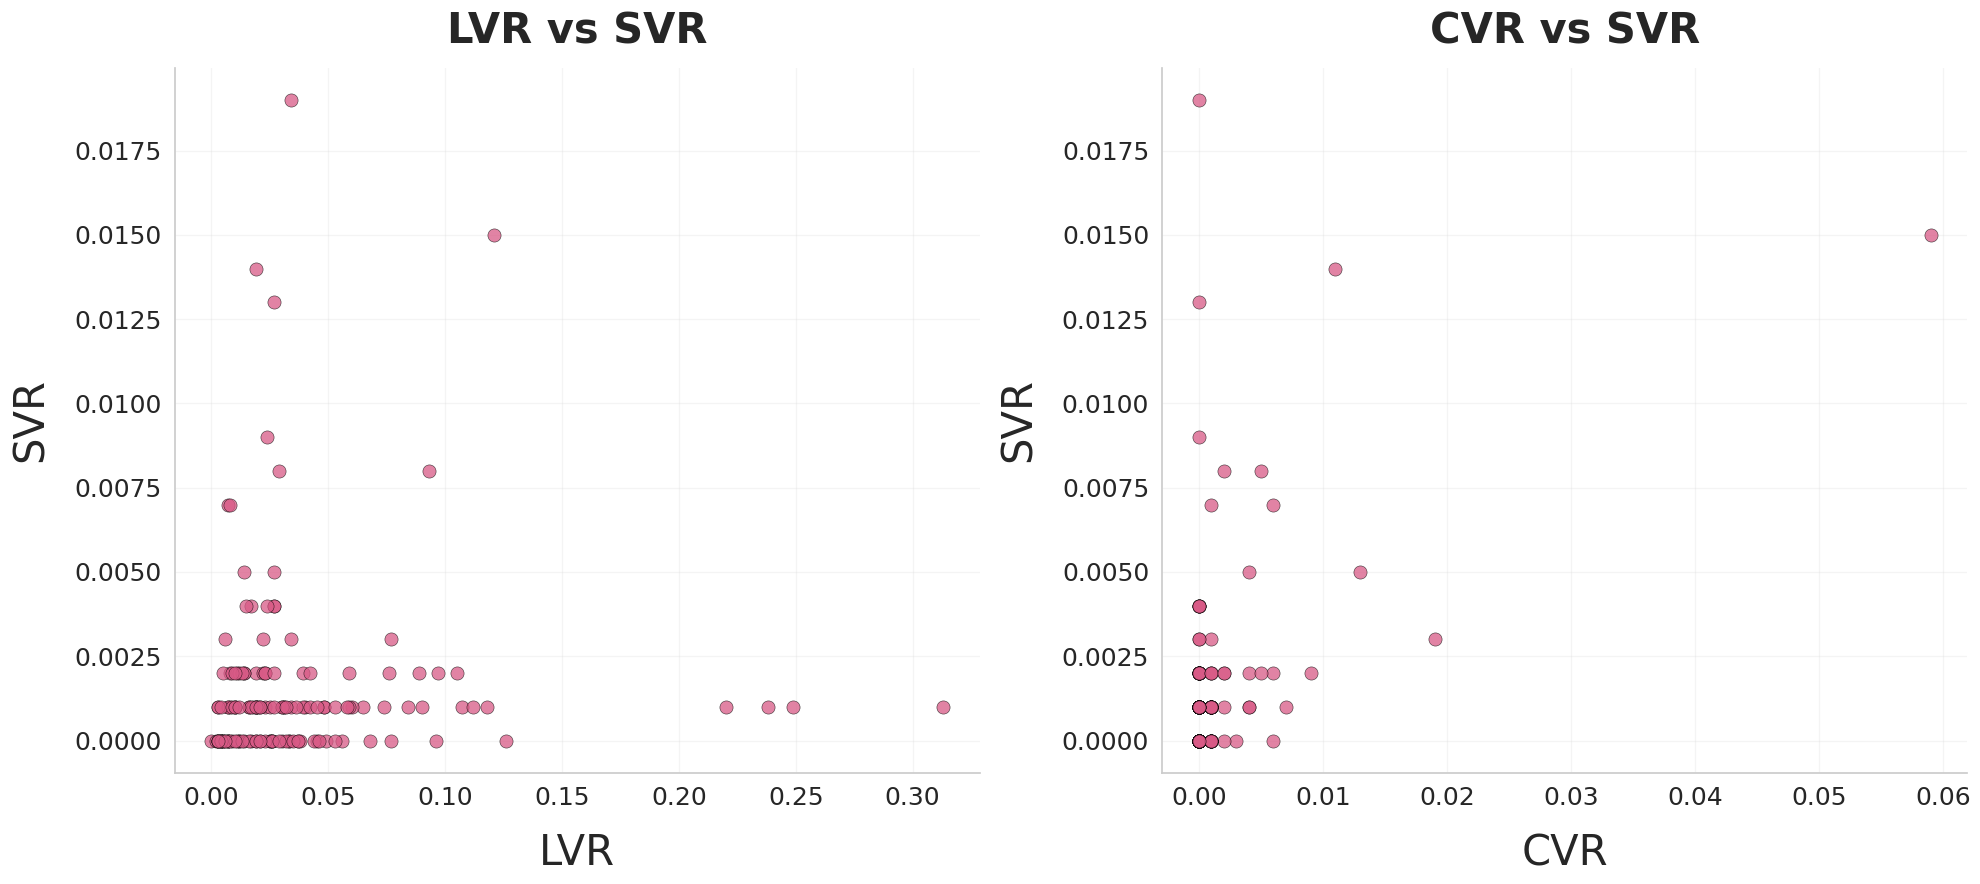

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

pairs = [('lvr', 'svr'),
         ('cvr', 'svr')]

for ax, pair in zip(axes, pairs):

    sns.scatterplot(
        data=df_model,
        x=pair[0],
        y=pair[1],
        color='#D85A86',
        s=90,
        alpha=0.75,
        edgecolor='black',
        linewidth=0.4,
        ax=ax
    )

    ax.set_title(
        f'{pair[0].upper()} vs {pair[1].upper()}',
        fontsize=30,
        weight='bold',
        pad=18
    )

    ax.set_xlabel(pair[0].upper(), fontsize=30, labelpad=16)
    ax.set_ylabel(pair[1].upper(), fontsize=30, labelpad=16)

    ax.tick_params(axis='both', labelsize=18)

    ax.grid(alpha=0.2)

sns.despine()
plt.tight_layout()

plt.savefig(
    'scatter_lvr_svr_cvr_svr.png',
    dpi=400,
    bbox_inches='tight'
)

plt.show()

## **Model Building (IForest)**

### **Perbandingan Kombinasi Fitur**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import pandas as pd

feature_combine = {
    "Seluruh fitur": ["er", "lvr", "cvr", "svr"],
    "ER-LVR-CVR": ["er", "lvr", "cvr"],
    "ER-LVR-SVR": ["er", "lvr", "svr"],
    "ER-CVR-SVR": ["er", "cvr", "svr"],
    "LVR-CVR-SVR": ["lvr", "cvr", "svr"],
    "ER-LVR": ["er", "lvr"],
    "ER-CVR": ["er", "cvr"],
    "ER-SVR": ["er", "svr"],
    "LVR-CVR": ["lvr", "cvr"],
    "LVR-SVR": ["lvr", "svr"],
    "CVR-SVR": ["cvr", "svr"]
}

tier_col = "kol_tier"   # ganti kalau nama kolom tier kamu beda
post_col = "post_code"

combine_results = []

for combine_name, features in feature_combine.items():

    all_anomalies = []

    for tier, df_tier in df_model.groupby(tier_col):

        X = df_tier[features].astype(float)

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        iso = IsolationForest(
            n_estimators=100,
            max_samples=len(df_tier),   # 30 per tier
            contamination=0.05,
            random_state=42
        )

        preds = iso.fit_predict(X_scaled)

        df_temp = df_tier.copy()
        df_temp["anomaly_flag"] = preds

        anomalies = df_temp.loc[
            df_temp["anomaly_flag"] == -1,
            post_col
        ].tolist()

        all_anomalies.extend(anomalies)

    combine_results.append({
        "Kombinasi": combine_name,
        "Fitur": ", ".join(features),
        "Jumlah Anomali": len(all_anomalies),
        "Postingan Terindikasi Anomali": all_anomalies
    })

combine_df = pd.DataFrame(combine_results)
combine_df

,Kombinasi,Fitur,Jumlah Anomali,Postingan Terindikasi Anomali
0,Seluruh fitur,"er, lvr, cvr, svr",10,"[post_83, post_173, post_266, post_296, post_7..."
1,ER-LVR-CVR,"er, lvr, cvr",10,"[post_83, post_173, post_266, post_296, post_9..."
2,ER-LVR-SVR,"er, lvr, svr",10,"[post_140, post_173, post_239, post_296, post_..."
3,ER-CVR-SVR,"er, cvr, svr",10,"[post_140, post_173, post_239, post_266, post_..."
4,LVR-CVR-SVR,"lvr, cvr, svr",10,"[post_140, post_173, post_239, post_266, post_..."
5,ER-LVR,"er, lvr",10,"[post_173, post_174, post_240, post_296, post_..."
6,ER-CVR,"er, cvr",10,"[post_83, post_173, post_266, post_296, post_9..."
7,ER-SVR,"er, svr",10,"[post_140, post_173, post_239, post_296, post_..."
8,LVR-CVR,"lvr, cvr",10,"[post_83, post_173, post_266, post_296, post_9..."
9,LVR-SVR,"lvr, svr",10,"[post_140, post_173, post_239, post_296, post_..."


In [ ]:
baseline = set(
    combine_df.loc[
        combine_df["Kombinasi"] == "Seluruh fitur",
        "Postingan Terindikasi Anomali"
    ].iloc[0]
)

combine_df["Irisan dengan Seluruh Fitur"] = combine_df["Postingan Terindikasi Anomali"].apply(
    lambda posts: len(set(posts) & baseline)
)

combine_df["Postingan Irisan"] = combine_df["Postingan Terindikasi Anomali"].apply(
    lambda posts: sorted(list(set(posts) & baseline))
)

combine_df

,Kombinasi,Fitur,Jumlah Anomali,Postingan Terindikasi Anomali,Irisan dengan Seluruh Fitur,Postingan Irisan
0,Seluruh fitur,"er, lvr, cvr, svr",10,"[post_83, post_173, post_266, post_296, post_7...",10,"[post_100, post_173, post_194, post_2, post_26..."
1,ER-LVR-CVR,"er, lvr, cvr",10,"[post_83, post_173, post_266, post_296, post_9...",9,"[post_100, post_173, post_194, post_2, post_26..."
2,ER-LVR-SVR,"er, lvr, svr",10,"[post_140, post_173, post_239, post_296, post_...",7,"[post_100, post_173, post_2, post_288, post_29..."
3,ER-CVR-SVR,"er, cvr, svr",10,"[post_140, post_173, post_239, post_266, post_...",7,"[post_100, post_173, post_194, post_266, post_..."
4,LVR-CVR-SVR,"lvr, cvr, svr",10,"[post_140, post_173, post_239, post_266, post_...",7,"[post_100, post_173, post_194, post_2, post_26..."
5,ER-LVR,"er, lvr",10,"[post_173, post_174, post_240, post_296, post_...",5,"[post_100, post_173, post_288, post_296, post_62]"
6,ER-CVR,"er, cvr",10,"[post_83, post_173, post_266, post_296, post_9...",8,"[post_100, post_173, post_194, post_266, post_..."
7,ER-SVR,"er, svr",10,"[post_140, post_173, post_239, post_296, post_...",7,"[post_100, post_173, post_194, post_288, post_..."
8,LVR-CVR,"lvr, cvr",10,"[post_83, post_173, post_266, post_296, post_9...",9,"[post_100, post_173, post_194, post_2, post_26..."
9,LVR-SVR,"lvr, svr",10,"[post_140, post_173, post_239, post_296, post_...",7,"[post_100, post_173, post_194, post_288, post_..."


**Heatmap Korelasi**

In [ ]:
corr_features = df_model[['er','lvr','cvr','svr']].corr()

corr_features.rename(
    columns={
        'er':'ER',
        'lvr':'LVR',
        'cvr':'CVR',
        'svr':'SVR'
    },
    index={
        'er':'ER',
        'lvr':'LVR',
        'cvr':'CVR',
        'svr':'SVR'
    },
    inplace=True
)

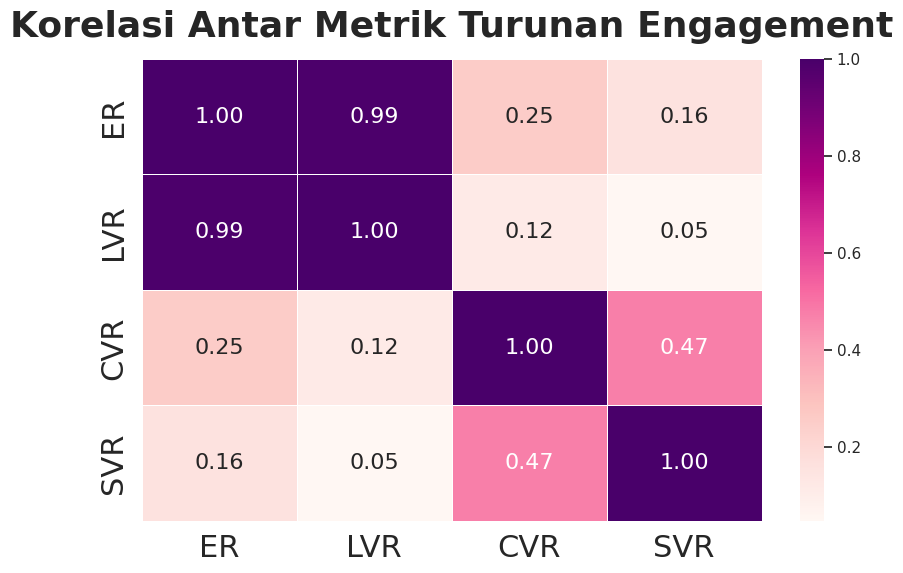

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_features,
    annot=True,
    fmt=".2f",
    cmap="RdPu",
    linewidths=0.5,
    annot_kws={"size":16}
)

plt.title(
    "Korelasi Antar Metrik Turunan Engagement",
    fontsize=26,
    weight='bold',
    pad=16
)

plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

plt.show()

**Kontribusi pembentuk ER**

In [ ]:
component_mean = df_model[["lvr", "cvr", "svr"]].mean().reset_index()
component_mean.columns = ["Komponen", "Rata-rata"]

component_mean["Persentase Kontribusi"] = (
    component_mean["Rata-rata"] / component_mean["Rata-rata"].sum() * 100
)

component_mean

,Komponen,Rata-rata,Persentase Kontribusi
0,lvr,0.036720,92.618127
1,cvr,0.001347,3.396671
2,svr,0.001580,3.985203


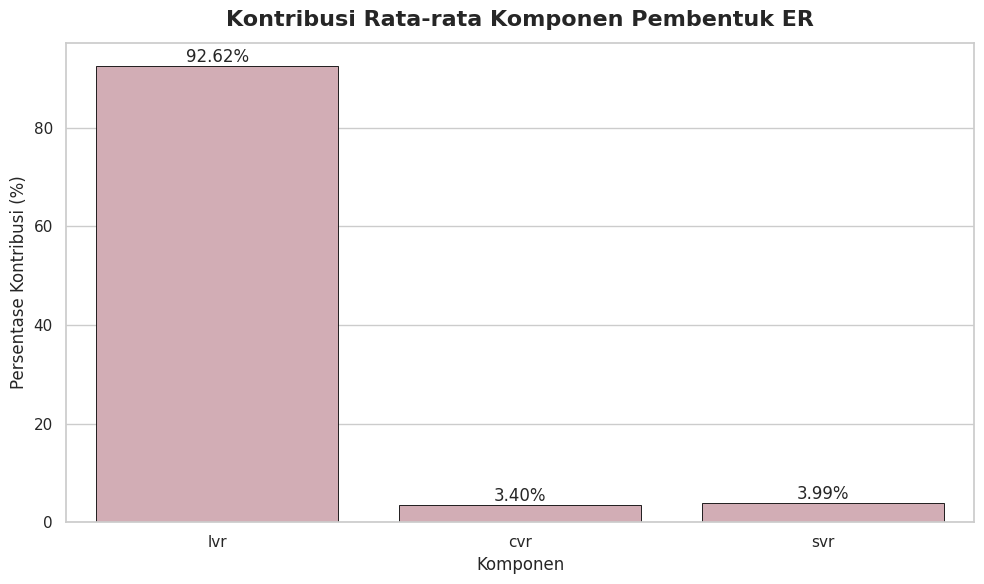

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=component_mean,
    x="Komponen",
    y="Persentase Kontribusi",
    color="#D8A7B1",
    edgecolor="black",
    linewidth=0.6
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}%',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.title(
    "Kontribusi Rata-rata Komponen Pembentuk ER",
    fontsize=16,
    weight="bold",
    pad=12
)

plt.xlabel("Komponen")
plt.ylabel("Persentase Kontribusi (%)")
plt.tight_layout()
plt.savefig("kontribusi_komponen_er.png", dpi=300, bbox_inches="tight")
plt.show()

**Kontribusi Fitur Model**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

features = ["er", "lvr", "cvr", "svr"]

X = df_model[features].astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=100,
    max_samples=30,
    contamination=0.05,
    random_state=42
)

iso.fit(X_scaled)

# scorer harus nerima estimator, X, y=None
def iforest_scorer(estimator, X, y=None):
    return estimator.score_samples(X).mean()

result = permutation_importance(
    iso,
    X_scaled,
    y=None,
    scoring=iforest_scorer,
    n_repeats=30,
    random_state=42
)

importance_df = pd.DataFrame({
    "Fitur": features,
    "Kontribusi": np.abs(result.importances_mean)
}).sort_values(by="Kontribusi", ascending=False)

importance_df

,Fitur,Kontribusi
0,er,0.002862
2,cvr,0.002437
3,svr,0.001941
1,lvr,0.001832


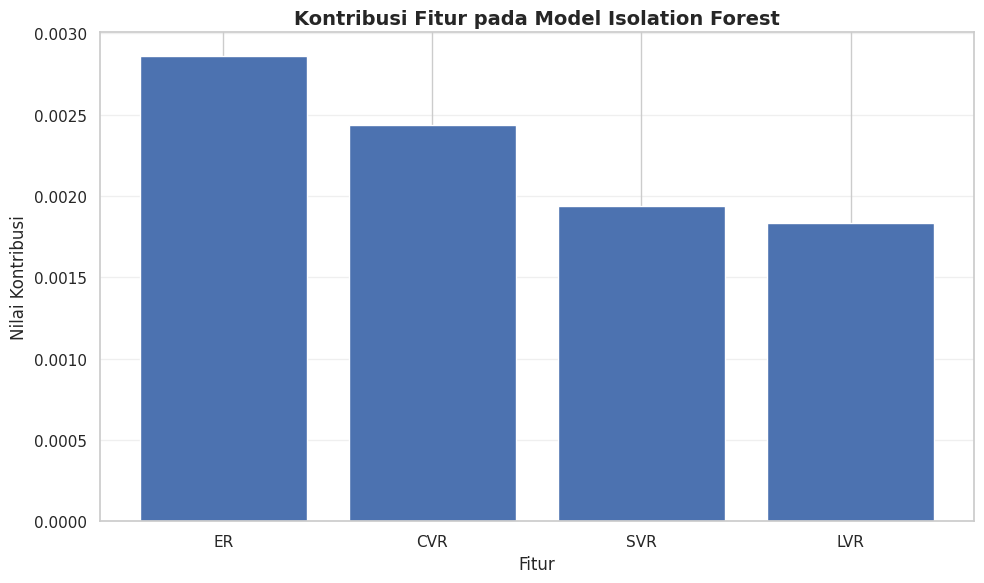

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    importance_df["Fitur"].str.upper(),
    importance_df["Kontribusi"]
)

plt.title("Kontribusi Fitur pada Model Isolation Forest", fontsize=14, weight="bold")
plt.xlabel("Fitur")
plt.ylabel("Nilai Kontribusi")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("kontribusi_fitur_iforest.png", dpi=300, bbox_inches="tight")
plt.show()

### **Pemodelan menggunakan fitur input ER-LVR**

In [ ]:
final_features = ["er", "lvr"]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

### **Analisis sensitivitas Parameter Contamination**

In [ ]:
contamination_list = [0.03, 0.05, 0.10]

cont_results = []

for cont in contamination_list:
    all_anomalies = []

    for tier in df_model["kol_tier"].dropna().unique():
        df_t = df_model[df_model["kol_tier"] == tier].copy()

        X = df_t[final_features].astype(float)

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        iso = IsolationForest(
            n_estimators=100,
            max_samples=30,
            contamination=cont,
            random_state=42
        )

        preds = iso.fit_predict(X_scaled)

        df_t["anomaly_flag"] = preds

        anomalies = df_t[df_t["anomaly_flag"] == -1]["post_code"].tolist()
        all_anomalies.extend(anomalies)

    cont_results.append({
        "contamination": cont,
        "Jumlah Anomali": len(all_anomalies),
        "Postingan Anomali": all_anomalies
    })

cont_df = pd.DataFrame(cont_results)
cont_df

,contamination,Jumlah Anomali,Postingan Anomali
0,0.03,5,"[post_62, post_100, post_288, post_173, post_296]"
1,0.05,10,"[post_1, post_62, post_7, post_100, post_286, ..."
2,0.10,15,"[post_1, post_2, post_62, post_7, post_100, po..."


### **Analisis Sensitivitas Parameter Max_Samples**

In [ ]:
max_samples_list = [15, 24, 30]

sample_results = []

for sample in max_samples_list:
    all_anomalies = []

    for tier in df_model["kol_tier"].dropna().unique():
        df_t = df_model[df_model["kol_tier"] == tier].copy()

        X = df_t[final_features].astype(float)

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        iso = IsolationForest(
            n_estimators=100,
            max_samples=sample,
            contamination=0.05,
            random_state=42
        )

        preds = iso.fit_predict(X_scaled)

        df_t["anomaly_flag"] = preds

        anomalies = df_t[df_t["anomaly_flag"] == -1]["post_code"].tolist()
        all_anomalies.extend(anomalies)

    sample_results.append({
        "max_samples": sample,
        "Jumlah Anomali": len(all_anomalies),
        "Postingan Anomali": all_anomalies
    })

sample_df = pd.DataFrame(sample_results)
sample_df

,max_samples,Jumlah Anomali,Postingan Anomali
0,15,10,"[post_2, post_62, post_100, post_252, post_286..."
1,24,10,"[post_2, post_62, post_100, post_252, post_286..."
2,30,10,"[post_1, post_62, post_7, post_100, post_286, ..."


### **Analisis sensitivitas gabungan**

In [ ]:
parameter_sets = [
    {"contamination": 0.05,  "max_samples": 30},
    {"contamination": 0.02,  "max_samples": 17},
    {"contamination": 0.08,  "max_samples": 41},
    {"contamination": 0.11,  "max_samples": 23},
    {"contamination": 0.035, "max_samples": 50},
    {"contamination": 0.06,  "max_samples": 12},
    {"contamination": 0.09,  "max_samples": 35}
]

results = []

for params in parameter_sets:

    all_anomalies = []

    for tier in df_model["kol_tier"].dropna().unique():

        df_t = df_model[df_model["kol_tier"] == tier].copy()

        X = df_t[final_features].astype(float)

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        iso = IsolationForest(
            n_estimators=100,
            contamination=params["contamination"],
            max_samples=params["max_samples"],
            random_state=42
        )

        preds = iso.fit_predict(X_scaled)

        df_t["anomaly_flag"] = preds

        anomalies = df_t[df_t["anomaly_flag"] == -1]["post_code"].tolist()

        all_anomalies.extend(anomalies)

    results.append({
        "Contamination": params["contamination"],
        "Max Samples": params["max_samples"],
        "Jumlah Anomali": len(all_anomalies),
        "Postingan Anomali": sorted(all_anomalies)
    })

results_df = pd.DataFrame(results)

results_df

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_iforest.py:336: UserWarning: max_samples (41) is greater than the total number of samples (30). max_samples will be set to n_samples for estimation.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_iforest.py:336: UserWarning: max_samples (41) is greater than the total number of samples (30). max_samples will be set to n_samples for estimation.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_iforest.py:336: UserWarning: max_samples (41) is greater than the total number of samples (30). max_samples will be set to n_samples for estimation.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_iforest.py:336: UserWarning: max_samples (41) is greater than the total number of samples (30). max_samples will be set to n_samples for estimation.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_iforest.py:336: UserWarning: max_samples (41) is greater than the total number of 

,Contamination,Max Samples,Jumlah Anomali,Postingan Anomali
0,0.050,30,10,"[post_1, post_100, post_173, post_174, post_24..."
1,0.020,17,5,"[post_100, post_173, post_288, post_296, post_62]"
2,0.080,41,15,"[post_1, post_100, post_150, post_171, post_17..."
3,0.110,23,20,"[post_1, post_100, post_104, post_150, post_17..."
4,0.035,50,10,"[post_1, post_100, post_173, post_174, post_24..."
5,0.060,12,10,"[post_100, post_171, post_173, post_2, post_24..."
6,0.090,35,15,"[post_1, post_100, post_150, post_171, post_17..."


In [ ]:
baseline = set(results_df.iloc[0]["Postingan Anomali"])

jumlah_konsisten = []

for posts in results_df["Postingan Anomali"]:
    jumlah_konsisten.append(len(baseline.intersection(set(posts))))

results_df["Jumlah Postingan Konsisten"] = jumlah_konsisten

results_df

,Contamination,Max Samples,Jumlah Anomali,Postingan Anomali,Jumlah Konsisten,Persentase Konsisten (%),Jumlah Postingan Konsisten
0,0.050,30,10,"[post_1, post_100, post_173, post_174, post_24...",10,100.0,10
1,0.020,17,5,"[post_100, post_173, post_288, post_296, post_62]",5,50.0,5
2,0.080,41,15,"[post_1, post_100, post_150, post_171, post_17...",10,100.0,10
3,0.110,23,20,"[post_1, post_100, post_104, post_150, post_17...",10,100.0,10
4,0.035,50,10,"[post_1, post_100, post_173, post_174, post_24...",10,100.0,10
5,0.060,12,10,"[post_100, post_171, post_173, post_2, post_24...",7,70.0,7
6,0.090,35,15,"[post_1, post_100, post_150, post_171, post_17...",10,100.0,10


In [ ]:
from collections import Counter

counter = Counter()

for posts in results_df["Postingan Anomali"]:
    counter.update(posts)

freq_df = (
    pd.DataFrame(counter.items(),
                 columns=["Post_Code","Frekuensi"])
      .sort_values("Frekuensi",ascending=False)
)

freq_df

,Post_Code,Frekuensi
1,post_100,7
2,post_173,7
6,post_288,7
7,post_296,7
8,post_62,7
5,post_286,6
4,post_240,6
0,post_1,5
3,post_174,5
9,post_7,5


### **Deteksi Per Tier**

In [ ]:
results_tier = []
all_tier_data = []

for tier in df_model["kol_tier"].dropna().unique():

    df_t = df_model[
        df_model["kol_tier"] == tier
    ].copy()

    X = df_t[final_features].astype(float)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    iso = IsolationForest(
    n_estimators=100,
    max_samples="30",
    contamination=0.05,
    random_state=42
)

    # preds = iso.fit_predict(X_scaled)

    df_t["anomaly_flag"] = preds
    outliers = df_t[
        df_t["anomaly_flag"] == -1
    ]

    results_tier.append({
        "kol_tier": tier,
        "n_data": len(df_t),
        "n_outliers": len(outliers),
        "outlier_post":
        ",".join(
            outliers["post_code"]
            .astype(str)
            .tolist()
        )
    })

    all_tier_data.append(df_t)

In [ ]:
results_tier_df = pd.DataFrame(results_tier)
results_tier_df

,kol_tier,n_data,n_outliers,outlier_post
0,Nano,30,2,"post_214,post_274"
1,Micro,30,2,"post_222,post_277"
2,Midi,30,2,"post_227,post_286"
3,Macro,30,2,"post_234,post_289"
4,Mega,30,2,"post_240,post_296"


### **Anomaly Score**

In [ ]:
results_tier = []
all_tier_data = []

for tier in df_model["kol_tier"].dropna().unique():

    df_t = df_model[df_model["kol_tier"] == tier].copy()

    X = df_t[final_features].astype(float)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    iso = IsolationForest(
        contamination=0.05,
        random_state=42
    )

    preds = iso.fit_predict(X_scaled)
    scores = iso.decision_function(X_scaled)

    df_t["anomaly_flag"] = preds
    df_t["anomaly_score"] = scores
    df_t["anomaly_indication"] = df_t["anomaly_flag"].map({
        -1: "Indikasi Anomali",
         1: "Indikasi Normal"
    })

    outliers = df_t[df_t["anomaly_flag"] == -1]

    results_tier.append({
        "kol_tier": tier,
        "n_data": len(df_t),
        "n_outliers": len(outliers),
        "outlier_post": ",".join(outliers["post_code"].astype(str).tolist())
    })

    all_tier_data.append(df_t)

results_tier_df = pd.DataFrame(results_tier)
final_df = pd.concat(all_tier_data, ignore_index=True)

In [ ]:
final_df = pd.concat(all_tier_data, ignore_index=True)

In [ ]:
final_df[["post_code", "kol_tier", "anomaly_flag", "anomaly_score", "anomaly_indication"]] \
    .sort_values(["kol_tier", "anomaly_score"])

,post_code,kol_tier,anomaly_flag,anomaly_score,anomaly_indication
106,post_173,Macro,-1,-0.109945,Indikasi Anomali
107,post_174,Macro,-1,-0.000345,Indikasi Anomali
105,post_171,Macro,1,0.000422,Indikasi Normal
117,post_289,Macro,1,0.077823,Indikasi Normal
95,post_51,Macro,1,0.089448,Indikasi Normal
...,...,...,...,...,...
27,post_274,Nano,1,0.276855,Indikasi Normal
20,post_186,Nano,1,0.277878,Indikasi Normal
9,post_91,Nano,1,0.279164,Indikasi Normal
24,post_241,Nano,1,0.281171,Indikasi Normal


In [ ]:
final_df.to_excel(
    "final_anomaly_fix.xlsx",
    index=False
)

from google.colab import files
files.download("final_anomaly_fix.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Eksperimen singkat**

### **Perbandingan Penggunaan Metrik Asli dan Metrik Turunan**

In [ ]:
features = ["views","likes","comments","shares"]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

In [ ]:
results_tier_raw = []
all_tier_data_raw = []

for tier in df_model["kol_tier"].dropna().unique():

    df_t = df_model[
        df_model["kol_tier"] == tier
    ].copy()

    X = df_t[features].astype(float)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    iso = IsolationForest(
    n_estimators=100,
    max_samples="30",
    contamination=0.05,
    random_state=42
)

    # preds = iso.fit_predict(X_scaled)

    df_t["anomaly_flag"] = preds
    outliers = df_t[
        df_t["anomaly_flag"] == -1
    ]

    results_tier_raw.append({
        "kol_tier": tier,
        "n_data": len(df_t),
        "n_outliers": len(outliers),
        "outlier_post":
        ",".join(
            outliers["post_code"]
            .astype(str)
            .tolist()
        )
    })

    all_tier_data_raw.append(df_t)

In [ ]:
results_tier_raw = []
all_tier_data_raw = []

for tier in df_model["kol_tier"].dropna().unique():

    df_t = df_model[df_model["kol_tier"] == tier].copy()

    X = df_t[features].astype(float)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    iso = IsolationForest(
        contamination=0.05,
        random_state=42
    )

    preds = iso.fit_predict(X_scaled)
    scores = iso.decision_function(X_scaled)

    df_t["anomaly_flag"] = preds
    df_t["anomaly_score"] = scores
    df_t["anomaly_indication"] = df_t["anomaly_flag"].map({
        -1: "Indikasi Anomali",
         1: "Indikasi Normal"
    })

    outliers = df_t[df_t["anomaly_flag"] == -1]

    results_tier.append({
        "kol_tier": tier,
        "n_data": len(df_t),
        "n_outliers": len(outliers),
        "outlier_post": ",".join(outliers["post_code"].astype(str).tolist())
    })

    all_tier_data_raw.append(df_t)

results_tierraw_df = pd.DataFrame(results_tier_raw)
final_df_raw = pd.concat(all_tier_data_raw, ignore_index=True)

In [ ]:
final_df_raw = pd.concat(all_tier_data_raw, ignore_index=True)

In [ ]:
final_df_raw

,post_code,post_url,post_date,username_kol,followers,kol_tier,is_endorse,likes,comments,shares,views,lvr,cvr,svr,er,anomaly_flag,anomaly_score,anomaly_indication
0,post_1,https://www.tiktok.com/@mimaoo__/video/7553881...,2025-09-25,mimaoo__,1353,Nano,endorse,45,3,0,471,0.096,0.006,0.000,0.102,1,0.340808,Indikasi Normal
1,post_2,https://www.tiktok.com/@mimaoo__/video/7552552...,2025-09-21,mimaoo__,1353,Nano,endorse,41,1,0,325,0.126,0.003,0.000,0.129,1,0.343786,Indikasi Normal
2,post_3,https://www.tiktok.com/@mimaoo__/photo/7552384...,2025-09-21,mimaoo__,1353,Nano,endorse,28,2,0,854,0.033,0.002,0.000,0.035,1,0.337916,Indikasi Normal
3,post_31,https://www.tiktok.com/@artyasm/video/75380443...,2025-08-13,artyasm,1518,Nano,endorse,555,28,52,272400,0.002,0.000,0.000,0.002,1,0.047028,Indikasi Normal
4,post_34,https://www.tiktok.com/@artyasm/video/75406458...,2025-08-20,artyasm,1518,Nano,endorse,11,0,6,319,0.034,0.000,0.019,0.053,1,0.347642,Indikasi Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,post_266,https://vt.tiktok.com/ZSyY4avws/,2025-09-30,itsshaaaxx,2500000000,Mega,endorse,1207,29,27,15800,0.076,0.002,0.002,0.080,1,0.308199,Indikasi Normal
146,post_267,https://vt.tiktok.com/ZSyY4sUme/,2025-09-26,itsshaaaxx,2500000000,Mega,endorse,218,25,32,24300,0.009,0.001,0.001,0.011,1,0.302573,Indikasi Normal
147,post_296,https://vt.tiktok.com/ZSyYtbchU/,2025-10-16,cataalcorse,1100000000,Mega,endorse,153300,358,767,1300000,0.118,0.000,0.001,0.119,1,0.291024,Indikasi Normal
148,post_298,https://vt.tiktok.com/ZSyYttCW4/,2025-10-08,cataalcorse,1100000000,Mega,endorse,289800,445,2627,3900000,0.074,0.000,0.001,0.075,1,0.197018,Indikasi Normal


In [ ]:
anomali_raw = final_df_raw[final_df_raw['anomaly_flag'] == -1]

anomali_raw

,post_code,post_url,post_date,username_kol,followers,kol_tier,is_endorse,likes,comments,shares,views,lvr,cvr,svr,er,anomaly_flag,anomaly_score,anomaly_indication
9,post_91,https://vt.tiktok.com/ZSy8G19T4/,2025-10-14,azzahraargta_,9652,Nano,endorse,2498,59,175,325700,0.008,0.000,0.001,0.008,-1,-0.038478,Indikasi Anomali
12,post_121,https://vt.tiktok.com/ZSyN8exf1/,2025-07-08,saturnslovv,4869,Nano,endorse,12300,386,1704,1000000,0.012,0.000,0.002,0.014,-1,-0.163765,Indikasi Anomali
51,post_220,https://vt.tiktok.com/ZSyFyS9FN/,2025-10-14,oksh.y,50200,Micro,endorse,3843,51,119,348900,0.011,0.000,0.000,0.012,-1,-0.027553,Indikasi Anomali
53,post_222,https://vt.tiktok.com/ZSyFyg9MA/,2025-09-16,oksh.y,50200,Micro,endorse,6534,85,97,346400,0.019,0.000,0.000,0.019,-1,-0.097230,Indikasi Anomali
85,post_255,https://vt.tiktok.com/ZSyYQgm5m/,2025-10-07,kaylaschaeferr,54400,Midi,endorse,297100,1056,8386,9200000,0.032,0.000,0.001,0.033,-1,-0.066542,Indikasi Anomali
86,post_258,https://vt.tiktok.com/ZSyYCDtad/,2025-09-26,kaylaschaeferr,54400,Midi,endorse,149700,1805,5394,7200000,0.021,0.000,0.001,0.022,-1,-0.041325,Indikasi Anomali
93,post_49,https://vt.tiktok.com/ZSydCJqWT/,2025-10-08,_restiindahhh,747100,Macro,endorse,291700,8545,11400,8700000,0.034,0.001,0.001,0.036,-1,-0.019234,Indikasi Anomali
118,post_291,https://vt.tiktok.com/ZSyYGTjKe/,2025-10-07,jolinnaaa,502100,Macro,endorse,1500000,3479,20400,17800000,0.084,0.000,0.001,0.086,-1,-0.016692,Indikasi Anomali
141,post_236,https://vt.tiktok.com/ZSyF5hw1W/,2025-10-07,aqeelaaz_,5200000000,Mega,endorse,1500000,7925,27000,16900000,0.089,0.000,0.002,0.091,-1,-0.024580,Indikasi Anomali
142,post_239,https://vt.tiktok.com/ZSyF52uF5/,2025-10-01,aqeelaaz_,5200000000,Mega,endorse,1800000,17700,60800,23300000,0.077,0.001,0.003,0.081,-1,-0.111492,Indikasi Anomali


### **kombinasi raw metrics**

In [ ]:
final_df_raw.to_excel(
    "cek raw metrics.xlsx",
    index=False
)

from google.colab import files
files.download("cek raw metrics.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Evaluation**

Evaluasi dilakukan untuk menganalisis hasil deteksi anomali yang diperoleh dari model Isolation Forest. Karena penelitian ini menggunakan pendekatan unsupervised dan tidak memiliki ground truth label, evaluasi tidak dilakukan menggunakan metrik klasifikasi seperti accuracy, precision, recall, atau F1-score.

Sebagai gantinya, evaluasi dilakukan melalui analisis distribusi anomaly score, distribusi hasil deteksi, serta perbandingan karakteristik engagement antara data yang terindikasi normal dan data yang terindikasi anomali.

### **Distribusi Hasil Deteksi**

Analisis ini dilakukan untuk melihat jumlah data yang terindikasi sebagai potential normal dan potential anomaly berdasarkan threshold anomaly score yang telah ditentukan.

In [ ]:
label_count = (final_df["anomaly_indication"].value_counts().reset_index())

label_count.columns = ["kategori","jumlah"]
label_count

,kategori,jumlah
0,Indikasi Normal,140
1,Indikasi Anomali,10


/tmp/ipykernel_1461/2193912370.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


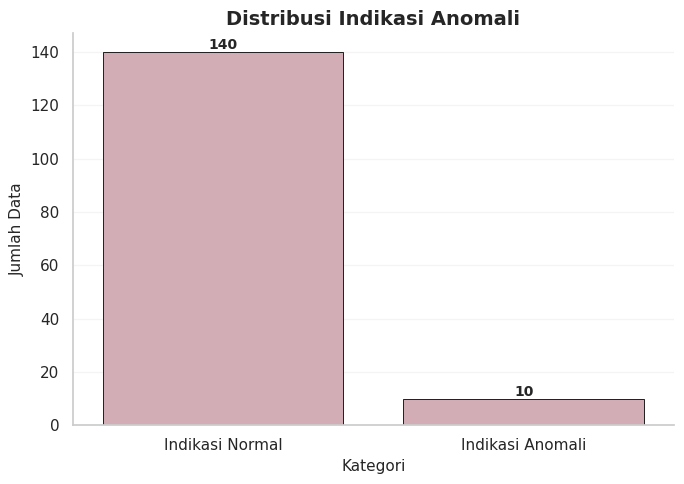

In [ ]:
plt.figure(figsize=(7,5))

colors = ['#D8A7B1', '#D8A7B1']

ax = sns.barplot(
    x=['Indikasi Normal', 'Indikasi Anomali'],
    y=[140, 10],
    palette=colors,
    edgecolor='black',
    linewidth=0.6)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold')

plt.title(
    'Distribusi Indikasi Anomali',
    fontsize=14,
    weight='bold'
)

plt.xlabel('Kategori', fontsize=11)
plt.ylabel('Jumlah Data', fontsize=11)
plt.grid(axis='y', alpha=0.2)
sns.despine()
plt.tight_layout()


plt.savefig(
    "distribusi_indikasi_anomali.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

/tmp/ipykernel_1461/2571673018.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


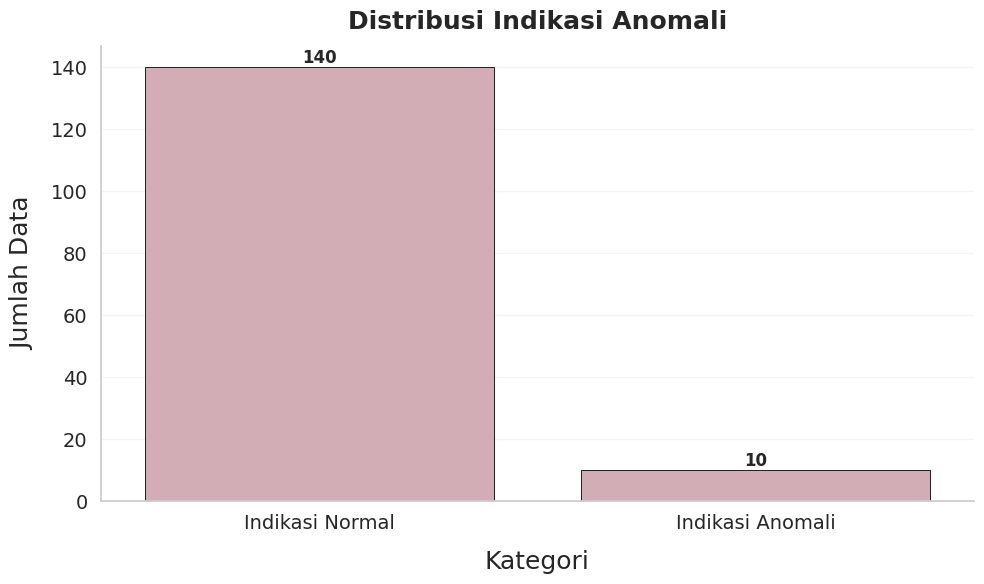

In [ ]:
plt.figure(figsize=(10,6))

colors = ['#D8A7B1', '#D8A7B1']

ax = sns.barplot(
    x=['Indikasi Normal', 'Indikasi Anomali'],
    y=[140, 10],   # ganti pake data aslimu
    palette=colors,
    edgecolor='black',
    linewidth=0.6
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=12,
        weight='bold'
    )

plt.title(
    'Distribusi Indikasi Anomali',
    fontsize=18,
    weight='bold',
    pad=12
)

plt.xlabel(
    'Kategori',
    fontsize=18,
    labelpad=12
)

plt.ylabel(
    'Jumlah Data',
    fontsize=18,
    labelpad=12
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.savefig(
    "distribusi_indikasi_anomali.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**Analisis Distribusi Indikasi Anomali**

---

Berdasarkan hasil pembentukan threshold skor anomali, data yang terindikasi sebagai anomali jauh lebih sedikit dibandingkan dengan data yang terindikasi normal. Berdasarkan hasil perbandingan visualisasi, data yang terindikasi anomali hanya sebanyak 8 data, sedangkan data terindikasi normal berjumlah 142.

### **DIstribusi Skor Anomali**

Distribusi skor anomali dianalisis untuk melihat pemisahan antara mayoritas data dan sebagian kecil data yang berada pada ekor distribusi dan terindikasi sebagai anomali.

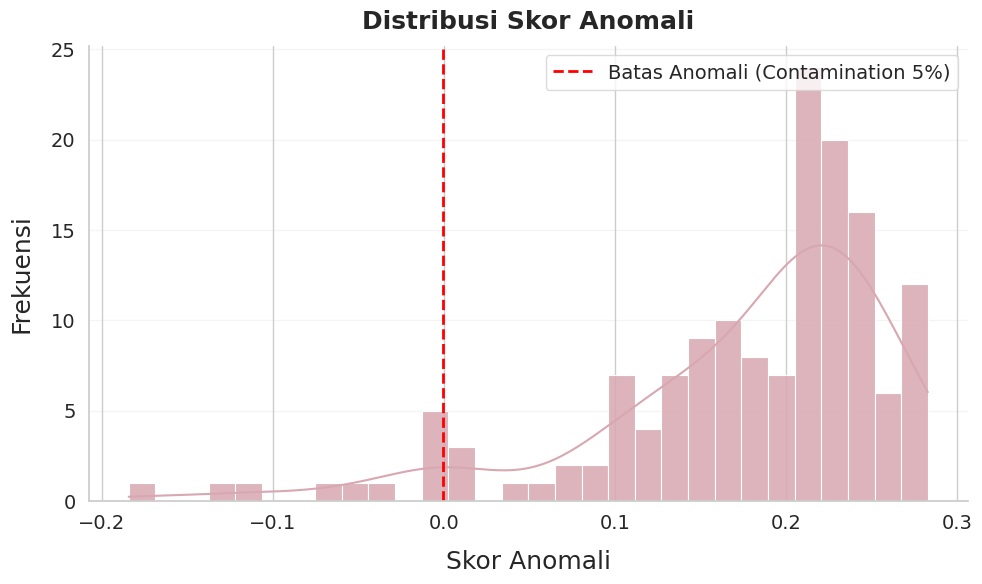

In [ ]:
batas_anomali = final_df.loc[
    final_df["anomaly_indication"] == "Indikasi Anomali",
    "anomaly_score"
].max()

plt.figure(figsize=(10,6))

sns.histplot(
    final_df["anomaly_score"],
    bins=30,
    kde=True,
    color="#D8A7B1",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.85
)

plt.axvline(
    batas_anomali,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Batas Anomali (Contamination 5%)"
)

plt.title(
    "Distribusi Skor Anomali",
    fontsize=18,
    weight='bold',
    pad=12
)

plt.xlabel(
    "Skor Anomali",
    fontsize=18,
    labelpad=12
)

plt.ylabel(
    "Frekuensi",
    fontsize=18,
    labelpad=12
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(
    fontsize=14,
    frameon=True,
    facecolor='white',
    edgecolor='lightgray'
)

plt.grid(axis='y', alpha=0.2)

sns.despine()

plt.tight_layout()

plt.savefig(
    "distribusi_skor_anomali.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

**Analisis Distribusi Skor Anomali**

---

Berdasarkan distribusi anomaly score, mayoritas data terkonsentrasi pada rentang skor positif yang menunjukkan karakteristik relatif normal menurut model Isolation Forest. Sementara itu, sebagian kecil data berada pada rentang skor yang lebih rendah dan membentuk ekor distribusi di sisi kiri, yang mengindikasikan adanya pola engagement yang berbeda dibanding mayoritas data lainnya.

Proses identifikasi anomali dilakukan menggunakan parameter contamination sebesar 5% pada model Isolation Forest. Melalui parameter tersebut, model secara otomatis mengelompokkan sebagian kecil data dengan tingkat penyimpangan tertinggi sebagai *Potential Anomaly*. Hasil distribusi menunjukkan bahwa model mampu memisahkan data dengan pola engagement yang menyimpang dari distribusi utama dataset.


### **Perbandingan Karakteristik Engagement**

Analisis ini dilakukan untuk membandingkan karakteristik metrik engagement antara data yang terindikasi normal dan data yang terindikasi anomali.

In [ ]:
comparison = (final_df.groupby("anomaly_indication")[["er","lvr","cvr","svr"]].mean())
comparison

,er,lvr,cvr,svr
anomaly_indication,,,,
Indikasi Anomali,0.1451,0.133000,0.008800,0.003200
Indikasi Normal,0.0323,0.029843,0.000814,0.001464


<Figure size 1000x600 with 0 Axes>

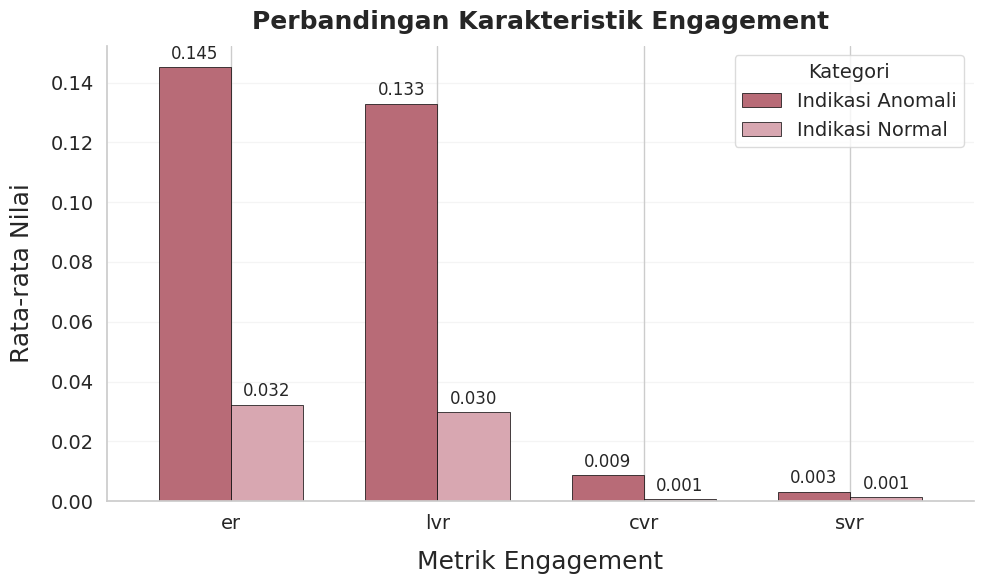

In [ ]:
plt.figure(figsize=(10,6))

colors = ['#B86B77', '#D8A7B1']

ax = comparison.T.plot(
    kind='bar',
    figsize=(10,6),
    color=colors,
    edgecolor='black',
    linewidth=0.5,
    width=0.7
)

# value di atas bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        fontsize=12,
        padding=3
    )

plt.title(
    'Perbandingan Karakteristik Engagement',
    fontsize=18,
    weight='bold',
    pad=12
)

plt.xlabel(
    'Metrik Engagement',
    fontsize=18,
    labelpad=12
)

plt.ylabel(
    'Rata-rata Nilai',
    fontsize=18,
    labelpad=12
)

plt.xticks(
    rotation=0,
    fontsize=14
)

plt.yticks(
    fontsize=14
)

plt.legend(
    title='Kategori',
    fontsize=14,
    title_fontsize=14,
    frameon=True,
    facecolor='white',
    edgecolor='lightgray'
)

plt.grid(
    axis='y',
    alpha=0.2
)

sns.despine()

plt.tight_layout()

plt.savefig(
    "perbandingan_karakteristik_engagement.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

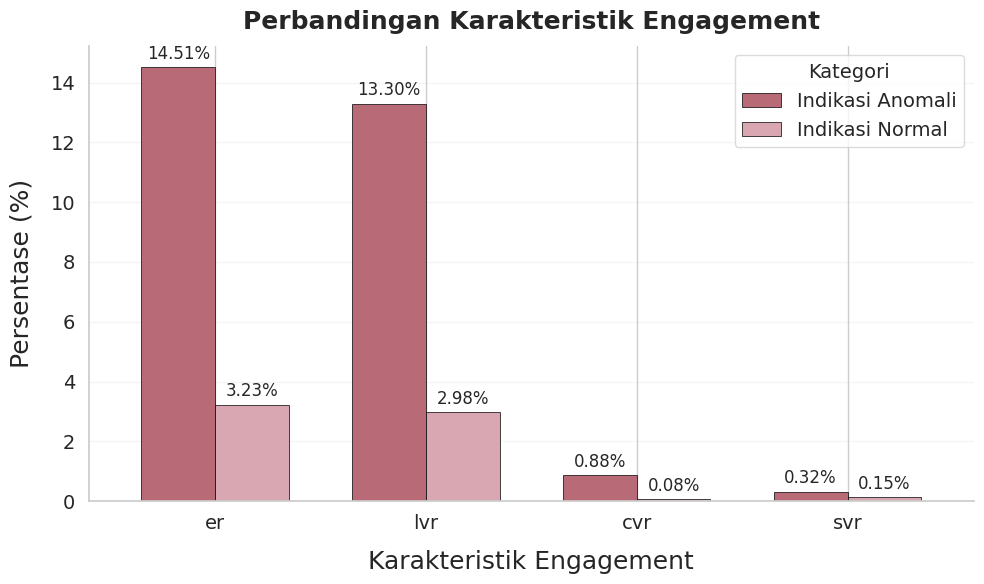

In [ ]:
comparison_percent = comparison * 100

colors = ['#B86B77', '#D8A7B1']

ax = comparison_percent.T.plot(
    kind='bar',
    figsize=(10,6),
    color=colors,
    edgecolor='black',
    linewidth=0.5,
    width=0.7
)

plt.title(
    "Perbandingan Karakteristik Engagement",
    fontsize=18,
    weight='bold',
    pad=12
)

plt.xlabel("Karakteristik Engagement", fontsize=18, labelpad=12)
plt.ylabel("Persentase (%)", fontsize=18, labelpad=12)

plt.xticks(rotation=0, fontsize=14)
plt.yticks(fontsize=14)

plt.legend(
    title='Kategori',
    fontsize=14,
    title_fontsize=14,
    frameon=True,
    facecolor='white',
    edgecolor='lightgray'
)

plt.grid(axis='y', alpha=0.2)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        fontsize=12,
        padding=3
    )

sns.despine()
plt.tight_layout()

plt.savefig(
    "perbandingan_karakteristik_engagement_persen.png",
    dpi=400,
    bbox_inches='tight'
)

plt.show()

**Analisis Indikasi Anomali**

---

Berdasarkan hasil perbandingan karakteristik engagement, terlihat bahwa data yang terindikasi sebagai *Potential Anomaly* memiliki nilai rata-rata ER dan LVR yang lebih tinggi dibandingkan mayoritas data normal. Hal ini menunjukkan bahwa postingan anomali cenderung memiliki tingkat interaksi yang lebih tinggi terhadap jumlah views dibandingkan pola umum pada dataset.

Selain itu, metrik CVR dan SVR juga menunjukkan nilai yang relatif lebih tinggi pada kelompok anomali, meskipun perbedaannya tidak sebesar ER dan LVR. Kondisi tersebut menunjukkan bahwa fitur ER dan LVR memiliki kontribusi yang lebih dominan dalam membedakan pola engagement menyimpang pada konten endorsement TikTok